# **Image and Video Technology and Analysis: Lab Exercise 2**
---

* **Peppas Michail-Athanasios**
* **03121026**
* **School of Electrical and Computer Engineering**
* **National Technical University of Athens**
* **Spring 2026**










# **What this Exercise is about**
---

This laboratory exercise studies the theory and practical application of **Convolutional Neural Networks (CNNs)** for image classification. The exercise connects three historically important CNN architectures - **LeNet**, **AlexNet**, and **VGG** - with an experimental classification task on a subset of the **CIFAR-100** dataset.

The theoretical part focuses on understanding how CNNs evolved from relatively small models for handwritten digit recognition to deeper architectures for large-scale natural image classification. The three reference papers represent three key stages in this evolution:

- **LeNet** introduced the fundamental CNN ideas: local receptive fields, shared weights, feature maps, and subsampling.
- **AlexNet** showed that deep CNNs can achieve state-of-the-art performance on large-scale image classification when combined with GPUs, ReLU activations, dropout, and data augmentation.
- **VGG** demonstrated that increasing network depth using simple repeated blocks of small $3 \times 3$ convolutional filters can significantly improve image classification performance.

The implementation part applies these ideas experimentally. We work with a team-specific subset of **CIFAR-100**, selected using the `team_seed` parameter. In this notebook, `team_seed = 26`, corresponding to the last three digits of the student ID number.

The main practical goals of the exercise are:

1. Load and inspect the selected CIFAR-100 subset.
2. Design and train four CNN models:
   - LeNet,
   - AlexNet,
   - VGG,
   - and a custom model, `MyCNN`.
3. Train all models under the same experimental configuration:
   - same optimizer,
   - same loss function,
   - same `batch_size`,
   - same number of epochs, namely $50$.
4. Evaluate model performance using the $F_1$-score.
5. Plot training and validation $F_1$-score curves to study learning behavior.
6. Analyze the effect of model capacity, optimizer choice, batch size, and dataset size.
7. Improve `MyCNN` using overfitting-control techniques, specifically dropout and data augmentation.
8. Apply transfer learning using pretrained VGG19 and EfficientNetB0 models.
9. Compare models trained from scratch with pretrained models and fine-tuned models.

Therefore, this exercise is not only about implementing CNN architectures, but also about understanding how architectural design choices affect generalization. In particular, it examines the role of convolutional filters, pooling, activation functions, depth, dropout, data augmentation, and transfer learning in image classification.

# **Part A: Theoretical Background and Comparative Analysis of LeNet, AlexNet, and VGG**
---

The theoretical part of the assignment is based on three important CNN papers:

1. **Handwritten Digit Recognition with a Back-Propagation Network**, associated with LeNet-style CNNs.
2. **ImageNet Classification with Deep Convolutional Neural Networks**, associated with AlexNet.
3. **Very Deep Convolutional Networks for Large-Scale Image Recognition**, associated with VGG.

These three works show the evolution of convolutional neural networks from small architectures for handwritten digit recognition to deeper models for large-scale image classification. Their main common idea is that images should not be treated as unstructured vectors of pixels. Instead, CNNs exploit the spatial structure of images through local connectivity, weight sharing, pooling, and hierarchical feature extraction.

---

## **1. LeNet: The Basic CNN Principles**

LeNet is one of the earliest successful convolutional neural network architectures. It was designed mainly for handwritten digit recognition, where the input images are small and relatively simple compared to modern natural image datasets.

The key contribution of LeNet is that it introduced the basic principles of CNNs:

- **Local receptive fields**: each neuron observes only a small local region of the input image.
- **Weight sharing**: the same convolutional filter is applied across different spatial positions.
- **Feature maps**: each filter produces a spatial map showing where a specific feature is detected.
- **Subsampling / average pooling**: spatial resolution is reduced to make the representation more tolerant to small translations and distortions.
- **End-to-end training with backpropagation**: the network learns its filters directly from data.

The main idea is that useful visual patterns, such as edges, curves, and local shapes, can appear anywhere in the image. By applying the same filter across the whole image, LeNet reduces the number of trainable parameters and improves generalization.

Compared to a fully connected network, LeNet is much more suitable for image data because it preserves spatial locality. A fully connected network would treat each pixel independently and would require many more parameters.

---

## **2. AlexNet: Scaling CNNs to Large-Scale Image Classification**

AlexNet extended CNNs to large-scale natural image classification. It was designed for ImageNet, a dataset with millions of RGB images and 1000 object categories. Compared to LeNet, AlexNet is much deeper, wider, and more computationally demanding.

The main innovations of AlexNet are:

- **Greater depth and capacity**: it contains 5 convolutional layers and 3 fully connected layers.
- **ReLU activation**: it uses $f(x)=\max(0,x)$, which trains faster than sigmoid or tanh because it reduces saturation effects.
- **GPU training**: the model was trained using GPUs, making large-scale CNN training practical.
- **Max pooling**: it uses max pooling, including overlapping pooling.
- **Local Response Normalization (LRN)**: used to encourage competition between neighboring feature maps.
- **Dropout**: applied in the fully connected layers to reduce overfitting.
- **Data augmentation**: random crops, horizontal flips, and color perturbations are used to increase the effective size of the training set.

AlexNet was important because it showed that learned CNN features can outperform traditional handcrafted computer vision features. Its success was not due to a single idea, but to the combination of large datasets, GPU computation, ReLU activations, dropout, data augmentation, and a high-capacity architecture.

---

## **3. VGG: Very Deep CNNs with Small Filters**

The VGG paper studied the effect of network depth on image classification performance. Its main conclusion is that increasing the depth of a CNN can significantly improve performance, provided that the architecture is designed carefully.

The main design choice in VGG is the systematic use of small $3 \times 3$ convolutional filters. Instead of using large filters such as $7 \times 7$ or $11 \times 11$, VGG stacks multiple $3 \times 3$ convolutions.

This has two important advantages:

1. **Larger effective receptive field through stacking**  
   Two consecutive $3 \times 3$ convolutional layers have an effective receptive field of $5 \times 5$, while three consecutive $3 \times 3$ layers have an effective receptive field of $7 \times 7$.

2. **More nonlinearities**  
   Since each convolution is followed by a ReLU, stacking small filters introduces more nonlinear transformations, making the network more expressive.

A typical VGG block has the form:

$$
\text{Conv } 3 \times 3
\rightarrow
\text{ReLU}
\rightarrow
\text{Conv } 3 \times 3
\rightarrow
\text{ReLU}
\rightarrow
\text{MaxPool}
$$

VGG architectures are simple and uniform. They mainly consist of repeated convolutional blocks followed by fully connected layers. VGG-16 and VGG-19 became widely used because their learned features transfer well to other computer vision tasks.

---

## **4. Comparative Table**

To avoid an overly wide table, the comparison is split into smaller tables. The same three architectures are compared with respect to task, structure, filters, activations, parameters, pooling, dropout, and performance.

### **4.1 General Overview**

| Characteristic | LeNet | AlexNet | VGG |
|---|---|---|---|
| Main task | Handwritten digit recognition | Large-scale ImageNet classification | Large-scale ImageNet classification |
| Input type | Small grayscale images | RGB natural images | RGB natural images |
| Main contribution | Introduced core CNN principles | Scaled CNNs to large datasets | Showed the importance of depth |
| Main idea | Local features and weight sharing | Deep CNNs with GPUs and ReLU | Very deep CNNs with repeated $3 \times 3$ blocks |

---

### **4.2 Network Structure**

| Characteristic | LeNet | AlexNet | VGG |
|---|---|---|---|
| Typical depth | Small CNN | 8 learned layers | 16-19 learned layers |
| Convolutional layers | Usually 2 in LeNet-5-style implementations | 5 convolutional layers | 13-16 convolutional layers in VGG-16/VGG-19 |
| Fully connected layers | Usually 3 | 3 | 3 |
| Approximate parameters | Tens of thousands in classical LeNet-style implementations | About 60 million | About 133-144 million |

---

### **4.3 Filters, Activations, and Pooling**

| Characteristic | LeNet | AlexNet | VGG |
|---|---|---|---|
| Filter sizes | Mainly $5 \times 5$ | $11 \times 11$, $5 \times 5$, $3 \times 3$ | Mostly $3 \times 3$ |
| Activation function | Sigmoid/tanh-like activations in the original formulation | ReLU | ReLU |
| Pooling | Average pooling / subsampling | Max pooling, including overlapping pooling | Max pooling with $2 \times 2$ windows and stride 2 |
| Dropout | Not used in the original architecture | Used in fully connected layers | Used in fully connected layers |

---

### **4.4 Regularization and Design Philosophy**

| Characteristic | LeNet | AlexNet | VGG |
|---|---|---|---|
| Regularization approach | Architectural constraints through locality and weight sharing | Dropout, data augmentation, and weight decay | Dropout, weight decay, and small-filter deep architecture |
| Main strength | Efficient and suitable for simple image tasks | Strong large-scale performance | Very deep, simple, and highly transferable visual features |
| Main limitation | Limited capacity for complex natural images | Large model with heavy fully connected layers | Very large number of parameters and high computational cost |

---

### **4.5 Performance-Oriented Discussion**

LeNet performs well on simple image recognition tasks because it uses the correct inductive biases for images: local receptive fields, shared weights, feature maps, and spatial subsampling. These choices reduce the number of free parameters and make the model suitable for handwritten digit recognition. However, its limited capacity makes it less appropriate for complex natural image datasets.

AlexNet greatly increases model capacity and introduces several important training techniques, such as ReLU activations, GPU acceleration, dropout, and data augmentation. These choices allowed CNNs to scale successfully to ImageNet. Compared to LeNet, AlexNet is deeper, wider, and much better suited for large-scale RGB image classification.

VGG focuses mainly on depth. Instead of using large convolutional filters, it stacks many small $3 \times 3$ filters. This creates deeper nonlinear feature hierarchies and improves representational power. Although VGG is architecturally simple, it has many parameters and high computational cost.

The evolution of the three architectures can be summarized as:

$$
\text{LeNet: basic CNN principles}
\rightarrow
\text{AlexNet: large-scale deep CNN training}
\rightarrow
\text{VGG: depth through repeated small-filter blocks}
$$

In the context of this exercise, these architectures are adapted and compared on a CIFAR-100 subset. Since CIFAR-100 images have size $32 \times 32 \times 3$, the original architectures may need to be adjusted. A model that is too small may underfit, while a very large model may overfit. Therefore, the comparison should consider not only final test performance, but also the training and validation $F_1$-score curves.

---

## **5. Performance and Design Discussion**

LeNet performs well on simple image recognition tasks because it uses the correct inductive biases for images: locality, weight sharing, and spatial hierarchy. However, its capacity is limited, so it is not sufficient for complex datasets with many object categories.

AlexNet greatly increases model capacity and introduces important training techniques such as ReLU activations, GPU acceleration, dropout, and data augmentation. These choices allow it to learn from large-scale image datasets and significantly improve classification performance.

VGG goes further by focusing on depth. Instead of using large convolutional filters, it stacks many small $3 \times 3$ filters. This creates deeper feature hierarchies and improves representational power. Although VGG is architecturally simple, it has many parameters and high computational cost.

The evolution of the three architectures can be summarized as:

$$
\text{LeNet: basic CNN principles}
\rightarrow
\text{AlexNet: large-scale deep CNN training}
\rightarrow
\text{VGG: depth through repeated small-filter blocks}
$$

In the context of this exercise, these architectures are adapted and compared on a CIFAR-100 subset. Since CIFAR-100 images have size $32 \times 32 \times 3$, the original architectures may need to be adjusted. A model that is too small may underfit, while a very large model may overfit. For this reason, the comparison must consider not only final test performance, but also the training and validation $F_1$-score curves.

Overall, the three papers show that successful CNN design depends on a balance between architectural bias, model capacity, regularization, available data, and computational resources.

# **Part B.1: Dataset Preparation and Inspection**
---

This preparatory section loads and prepares the dataset that will be used in the implementation part of the exercise.

First, the full **CIFAR-100** dataset is loaded using the fine-label version, where each image belongs to one of 100 detailed object classes. Then, using the `team_seed` value, a specific subset of **20 classes** is selected for this notebook. This makes the dataset unique for each student/team.

After selecting the class subset, the code keeps only the images whose labels belong to these 20 selected classes. The resulting data is then split into:

- a **training set**, used to train the models,
- a **validation set**, used to monitor generalization during training,
- a **test set**, used only for final evaluation.

The image pixel values are also normalized from the original range $[0,255]$ to the range $[0,1]$. This normalization helps neural networks train more smoothly and avoids very large input values.

The printed outputs show the shapes of the created datasets. For example:

- `x_train.shape` shows the number of training images and their dimensions.
- `y_train.shape` shows the number of training labels.
- `x_val.shape` and `y_val.shape` show the validation split.
- `x_test.shape` and `y_test.shape` show the final test set.

Since CIFAR-100 images have size $32 \times 32$ with 3 color channels, each image has shape:

$$
32 \times 32 \times 3
$$

The displayed sample images provide a visual check that the selected subset has been loaded correctly and that the labels correspond to the expected CIFAR-100 classes.

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals # legacy compatibility

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# helper functions

# select from from_list elements with index in index_list
def select_from_list(from_list, index_list):
  filtered_list= [from_list[i] for i in index_list]
  return(filtered_list)

# append in filtered_list the index of each element of unfilterd_list if it exists in in target_list
def get_ds_index(unfiliterd_list, target_list):
  index = 0
  filtered_list=[]
  for i_ in unfiliterd_list:
    if i_[0] in target_list:
      filtered_list.append(index)
    index += 1
  return(filtered_list)

# load the entire dataset
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(x_train_all, y_train_all), (x_test_all, y_test_all) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

print(x_train_all.shape)


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 412s 2us/step
(50000, 32, 32, 3)


Each team will work with a different subset of the dataset.
In the next cell, we replace the value of the `team_seed` variable with the number corresponding to our team. As the project was done as an individual, the `team_seed` variable will be set to the last 3 digits of my student ID number (03121026), i.e. 026, but it cannot start with 0, so 26 will be chosen.

In [ ]:
# REPLACE WITH YOUR TEAM NUMBER (student ID number in this case)
team_seed = 26

# select from CIFAR100 20 classes
cifar100_classes_url = "https://pastebin.com/raw/nzE1n98V"

We are creating our team's unique dataset:

In [ ]:
import io
import requests
import numpy as np
import pandas as pd

def read_csv_with_user_agent(url, sep=",", header=None):
    """
    Read a remote CSV while sending a browser-like User-Agent.

    This avoids HTTP 403 errors from services that reject the default
    Python / pandas / urllib request headers.
    """
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        )
    }

    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()

    return pd.read_csv(io.StringIO(response.text), sep=sep, header=header)


team_classes = read_csv_with_user_agent(
    cifar100_classes_url,
    sep=",",
    header=None
)

CIFAR100_LABELS_LIST = (
    read_csv_with_user_agent(
        "https://pastebin.com/raw/qgDaNggt",
        sep=",",
        header=None
    )
    .astype(str)
    .values
    .tolist()[0]
)

our_index = team_classes.iloc[team_seed, :].values.tolist()
our_classes = select_from_list(CIFAR100_LABELS_LIST, our_index)

train_index = get_ds_index(y_train_all, our_index)
test_index = get_ds_index(y_test_all, our_index)

x_train_ds = np.asarray(select_from_list(x_train_all, train_index))
y_train_ds = np.asarray(select_from_list(y_train_all, train_index))
x_test_ds = np.asarray(select_from_list(x_test_all, test_index))
y_test_ds = np.asarray(select_from_list(y_test_all, test_index))

print(our_classes)
print(x_train_ds[1].shape)

[' bus', ' chimpanzee', ' cloud', ' dinosaur', ' forest', ' fox', ' girl', ' hamster', ' lobster', ' motorcycle', ' oak_tree', ' pine_tree', ' seal', ' shrew', ' skunk', ' snake', ' sweet_pepper', ' telephone', ' tiger', ' worm']
(32, 32, 3)


Train: X=(8500, 32, 32, 3), y=(8500, 1)
Validation: X=(1500, 32, 32, 3), y=(1500, 1)
Test: X=(2000, 32, 32, 3), y=(2000, 1)


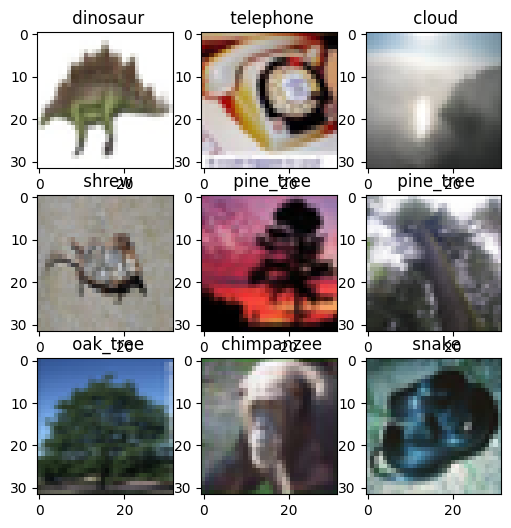

In [ ]:
# get (train) dataset dimensions
data_size, img_rows, img_cols, img_channels = x_train_ds.shape

# set validation set percentage (wrt the training set size)
validation_percentage = 0.15
val_size = round(validation_percentage * data_size)

# Reserve val_size samples for validation and normalize all values
x_val = x_train_ds[-val_size:]/255
y_val = y_train_ds[-val_size:]
x_train = x_train_ds[:-val_size]/255
y_train = y_train_ds[:-val_size]
x_test = x_test_ds/255
y_test = y_test_ds

# summarize loaded dataset
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Validation: X=%s, y=%s' % (x_val.shape, y_val.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

# get class label from class index
def class_label_from_index(fine_category):
  return(CIFAR100_LABELS_LIST[fine_category.item(0)])

# plot first few images
plt.figure(figsize=(6, 6))
for i in range(9):
	# define subplot
  plt.subplot(330 + 1 + i).set_title(class_label_from_index(y_train[i]))
	# plot raw pixel data
  plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
  #show the figure
plt.show()

## **Part B.2: CNN Training, Regularization, and Transfer Learning**
---

In this part, we implement the main experimental section of the exercise. The goal is to train, evaluate, and compare different CNN-based approaches on the selected 20-class CIFAR-100 subset.

This section is divided into three questions:

1. **Question 1 - CNN model implementation and comparison**  
   We design and train LeNet, AlexNet, VGG, and a custom model called `MyCNN`. All models are trained under the same experimental setup, using the same optimizer, loss function, `batch_size`, and number of epochs. Their performance is compared using the $F_1$-score.

2. **Question 2 - Overfitting control for MyCNN**  
   We focus only on `MyCNN` and test regularization techniques such as dropout and data augmentation. The goal is to improve the model's generalization ability and reduce the gap between training and validation performance.

3. **Question 3 - Transfer learning and fine-tuning**  
   We apply transfer learning using pretrained VGG19 and EfficientNetB0 models. First, the pretrained convolutional base is frozen and only a new classification head is trained. Then, part of the pretrained model is unfrozen and fine-tuned.

Across all three questions, the main evaluation criterion is the $F_1$-score on the validation and test sets. The final goal is to compare training from scratch, regularized training, and transfer learning in terms of classification performance and generalization.

## **Label Remapping for 20-Class Classification**
---

Before training the CNN models, the labels must be converted to a contiguous range.

Although this exercise uses only 20 selected CIFAR-100 classes, their original labels still come from the full CIFAR-100 label space, where labels range from 0 to 99. For example, the selected classes may have original labels such as 8, 23, 41, or 97.

However, the models in this exercise will use an output layer with exactly 20 neurons:

$$
\text{Dense}(20, \text{softmax})
$$

Therefore, when using sparse categorical cross-entropy, the target labels must be integers in the range:

$$
0, 1, 2, \ldots, 19
$$

This code cell remaps the original CIFAR-100 labels of the selected classes to new labels from 0 to 19. This ensures that the labels are compatible with the 20-class softmax output layer.

The printed output confirms:

- the number of selected classes,
- the input image shape,
- the new shape of each label array,
- and that the minimum and maximum labels are now 0 and 19 respectively.

In [ ]:
# Remap original CIFAR-100 labels to contiguous labels 0, 1, ..., 19

NUM_CLASSES = len(our_index)
INPUT_SHAPE = x_train.shape[1:]

# Optional cleanup: remove leading/trailing spaces from class names
our_classes = [class_name.strip() for class_name in our_classes]

label_to_new = {old_label: new_label for new_label, old_label in enumerate(our_index)}
new_to_label = {new_label: old_label for old_label, new_label in label_to_new.items()}

def remap_labels(y):
    y_flat = y.reshape(-1)
    return np.asarray([label_to_new[int(label)] for label in y_flat], dtype=np.int32)

y_train = remap_labels(y_train)
y_val = remap_labels(y_val)
y_test = remap_labels(y_test)

print("NUM_CLASSES:", NUM_CLASSES)
print("INPUT_SHAPE:", INPUT_SHAPE)
print("Train labels:", y_train.shape, y_train.min(), y_train.max())
print("Validation labels:", y_val.shape, y_val.min(), y_val.max())
print("Test labels:", y_test.shape, y_test.min(), y_test.max())
print("Class names:", our_classes)

NUM_CLASSES: 20
INPUT_SHAPE: (32, 32, 3)
Train labels: (8500,) 0 19
Validation labels: (1500,) 0 19
Test labels: (2000,) 0 19
Class names: ['bus', 'chimpanzee', 'cloud', 'dinosaur', 'forest', 'fox', 'girl', 'hamster', 'lobster', 'motorcycle', 'oak_tree', 'pine_tree', 'seal', 'shrew', 'skunk', 'snake', 'sweet_pepper', 'telephone', 'tiger', 'worm']


## **Question 1: Assignment**
---

### **Step 1: Model design and training**

**Design and train** the `LeNet`, `AlexNet`, and `VGG` models, as well as your own custom model, for example `MyCNN`.

All models must be trained using the **same**:

- optimization algorithm ([`optimizer`](https://keras.io/api/optimizers/)),
- cost function / loss function ([`loss`](https://keras.io/api/losses/)),
- `batch_size`,
- number of epochs: $50$.

To evaluate the **performance** of the models, use the $F_1$-score as the metric ([`metrics`](https://keras.io/api/metrics/)).


`*`  
You may experiment with the `optimizer`, `loss function`, and `batch_size` for the $4$ models before deciding on your final **common configuration** for all models.


---
  
### **Step 2: Model evaluation**

a. For each model trained in **Step 1**, plot the **training** and **validation** $F_1$-scores over all epochs in a **single diagram**.

b. Evaluate your results in detail with respect to the following:

- Effect of the **number of data samples/classes**.
- Effect of the optimization algorithm, i.e. the `optimizer`.
- Effect of the `batch_size`.

---

### **Step 3: $F_1$-score evaluation**

Evaluate the $F_1$-scores using your **test set**.

## **Question 1: Implementation Notes - Setup, Search Grid, and Model Definitions**
---

This cell defines the full experimental framework for **Question 1**. The goal is to implement, train, and compare four CNN architectures on the same **20-class CIFAR-100 subset**:

- `LeNet`
- `AlexNet`
- `VGG`
- `MyCNN`

All models receive RGB images of shape:

$$
32 \times 32 \times 3
$$

where the first two numbers are the image height and width, and the last number is the number of color channels: **red**, **green**, and **blue**.

All models end with:

```python
Dense(20, activation="softmax")
```

because our subset contains exactly **20 classes**. Therefore, the final number `20` is fixed by the classification task, not chosen freely. The `softmax` layer outputs one probability per class.

The original CIFAR-100 labels were already remapped to contiguous labels:

$$
0, 1, \ldots, 19
$$

so they are compatible with a `20`-unit output layer.

---

### **Hyperparameter Grid Search**

Before selecting the final common training setup, we perform a full grid search over:

| Parameter | Values |
|---|---|
| Model | `LeNet`, `AlexNet`, `VGG`, `MyCNN` |
| Optimizer | `Adam`, `AdamW`, `SGD` with momentum, `RMSprop` |
| Loss function | `SparseCategoricalCrossentropy`, `CategoricalCrossentropy`, `KLDivergence`, `MeanSquaredError` |
| Batch size | `32`, `64`, `128`, `256` |

This gives:

$$
4 \times 4 \times 4 \times 4 = 256
$$

short grid-search training runs.

The purpose of the grid search is to select **one common optimizer/loss/batch-size configuration** that performs well on average across all four models. We do not choose a different best setup for each model, because the final comparison must be fair. In the final comparison, the only major difference should be the **architecture**.

After the grid search, all four models are trained again from scratch for **50 epochs** using the selected common configuration.

---

### **Why These Optimizers Were Selected**

The optimizer grid contains four common Keras optimizers:

| Optimizer | Reason |
|---|---|
| `Adam` | Strong and stable default optimizer for CNN image classification |
| `AdamW` | Adam with weight decay, useful as a regularized optimizer |
| `SGD` with momentum | Classical CNN optimizer, close to the training style of AlexNet and VGG |
| `RMSprop` | Common adaptive optimizer and useful alternative to Adam |

Each optimizer uses a reasonable default learning-rate setup. The learning rate is not added as another grid dimension, because that would greatly increase the number of runs.

---

### **Why These Loss Functions Were Selected**

The loss grid contains four losses that can be used with a `softmax` classifier:

| Loss | Label Format | Reason |
|---|---|---|
| `SparseCategoricalCrossentropy` | Integer labels | Most direct choice for labels $0,\ldots,19$ |
| `CategoricalCrossentropy` | One-hot labels | Standard multi-class classification loss |
| `KLDivergence` | One-hot labels | Compares target and predicted probability distributions |
| `MeanSquaredError` | One-hot labels | Historical baseline for neural-network classifiers |

For `SparseCategoricalCrossentropy`, the labels remain integer class IDs. For the other losses, the labels are converted to one-hot vectors.

---

### **Why These Batch Sizes Were Selected**

The batch-size grid is:

$$
\{32, 64, 128, 256\}
$$

These values cover a practical range for CIFAR-sized CNN training:

| Batch Size | Interpretation |
|---:|---|
| `32` | Smaller batch, noisier gradients, often useful for generalization |
| `64` | Balanced default choice |
| `128` | Common CNN training batch size |
| `256` | Larger GPU-friendly batch size |

---

### **Architecture Choices for the Reference Models**

The reference architectures are adapted to the small CIFAR image size:

- `LeNet` is implemented as a small CNN with two convolutional stages, average pooling, and dense layers.
- `AlexNet` is implemented as a compact AlexNet-style CNN with ReLU activations, multiple convolutional layers, max pooling, and dropout in the classifier.
- `VGG` is implemented as a compact VGG-style CNN using repeated $3 \times 3$ convolutional blocks followed by max pooling.

The original AlexNet and VGG architectures were designed for much larger ImageNet images. Directly copying their full versions would be unnecessarily large for $32 \times 32$ CIFAR images, so we preserve their main architectural ideas while scaling them down.

---

### **Design of `MyCNN`**

`MyCNN` is our custom CNN for this assignment. It is designed specifically for $32 \times 32$ CIFAR images and is not a direct copy of `LeNet`, `AlexNet`, or `VGG`.

The architecture is:

| Stage | Operation | Output Shape |
|---|---|---|
| Input | RGB CIFAR image | $32 \times 32 \times 3$ |
| Block 1 | Two Conv-BN-ReLU layers with `32` filters, then MaxPool | $16 \times 16 \times 32$ |
| Block 2 | Two Conv-BN-ReLU layers with `64` filters, then MaxPool | $8 \times 8 \times 64$ |
| Block 3 | Two Conv-BN-ReLU layers with `128` filters | $8 \times 8 \times 128$ |
| Classifier | Global Average Pooling | $128$ |
| Classifier | Dense layer with ReLU | $128$ |
| Output | Dense layer with `softmax` | $20$ |

The convolutions use:

```python
padding="same"
```

so convolution does not reduce the image height and width. For example:

$$
32 \times 32 \times 3 \rightarrow 32 \times 32 \times 32
$$

The spatial size is reduced only by max pooling:

$$
32 \times 32 \rightarrow 16 \times 16 \rightarrow 8 \times 8
$$

The number of filters is our custom architectural choice:

$$
32 \rightarrow 64 \rightarrow 128
$$

This follows a standard CNN pattern: early layers keep high spatial detail with fewer filters, while deeper layers use more filters to learn more abstract visual features.

The final `Dense(20)` layer does not choose `20` features out of the previous `128` features. Instead, it learns `20` weighted combinations of all `128` features, one for each class. Mathematically, if the feature vector has shape $128$, the final dense layer learns a weight matrix of shape:

$$
128 \times 20
$$

and produces $20$ class scores, which `softmax` converts into class probabilities.

---

### **Why `MyCNN` Uses This Design**

The main design choices are:

| Design Choice | Reason |
|---|---|
| Small $3 \times 3$ convolutions | Suitable for CIFAR-sized images and useful for learning local visual patterns |
| Increasing filter depth: `32`, `64`, `128` | Gradually moves from simple low-level features to more complex high-level features |
| Batch Normalization after each convolution | Stabilizes training and helps the model work reliably across different optimizers |
| ReLU activations | Simple, efficient, and commonly used in modern CNNs |
| Max Pooling after the first two blocks | Reduces spatial resolution and makes the representation more compact |
| Global Average Pooling instead of Flatten | Reduces the number of parameters before the classifier and helps limit overfitting |
| No dropout and no data augmentation in Question 1 | Keeps `MyCNN` as a clean baseline; these overfitting-control methods are studied separately in Question 2 |

Therefore, `MyCNN` is a compact, modern, CIFAR-specific CNN with enough capacity to learn meaningful visual features while remaining appropriate for the relatively small **20-class dataset subset**.

In [ ]:
# ============================================================
# Question 1 - Cell 1
# Setup, helper functions, model definitions, and search grid
# Memory-safer / resumable version
# ============================================================

import os
import gc
import time
import random
import itertools
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models as keras_models
from sklearn.metrics import f1_score, accuracy_score
from IPython.display import display
from tqdm.auto import tqdm


# -----------------------------
# Reproducibility
# -----------------------------

SEED = 26

def set_global_seed(seed=SEED):
    """
    Set seeds for Python, NumPy, and TensorFlow.

    Full GPU determinism is not always guaranteed in Colab, but this makes
    the experiments as reproducible as reasonably possible.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    try:
        tf.keras.utils.set_random_seed(seed)
    except Exception:
        pass


def stable_seed(*parts, base_seed=SEED):
    """
    Create a deterministic integer seed from a list of configuration parts.
    This avoids Python's session-dependent hash randomization.
    """
    text = "|".join(str(part) for part in parts)
    value = sum((idx + 1) * ord(char) for idx, char in enumerate(text))

    return int((base_seed + value) % 2_000_000_000)


set_global_seed(SEED)


# -----------------------------
# Data cleanup and label formats
# -----------------------------

x_train = x_train.astype("float32")
x_val = x_val.astype("float32")
x_test = x_test.astype("float32")

y_train_int = np.asarray(y_train).reshape(-1).astype("int32")
y_val_int = np.asarray(y_val).reshape(-1).astype("int32")
y_test_int = np.asarray(y_test).reshape(-1).astype("int32")

y_train_oh = tf.keras.utils.to_categorical(
    y_train_int,
    num_classes=NUM_CLASSES,
).astype("float32")

y_val_oh = tf.keras.utils.to_categorical(
    y_val_int,
    num_classes=NUM_CLASSES,
).astype("float32")

y_test_oh = tf.keras.utils.to_categorical(
    y_test_int,
    num_classes=NUM_CLASSES,
).astype("float32")

INPUT_SHAPE = tuple(x_train.shape[1:])
EVAL_BATCH_SIZE = 256

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("Training set:", x_train.shape, y_train_int.shape)
print("Validation set:", x_val.shape, y_val_int.shape)
print("Test set:", x_test.shape, y_test_int.shape)


# -----------------------------
# Hyperparameter constants
# -----------------------------

GRID_EPOCHS = 3
FINAL_EPOCHS = 50

OPTIMIZER_GRID = [
    "adam",
    "adamw",
    "sgd_momentum",
    "rmsprop",
]

LOSS_GRID = [
    "sparse_categorical_crossentropy",
    "categorical_crossentropy",
    "kullback_leibler_divergence",
    "mean_squared_error",
]

BATCH_SIZE_GRID = [
    32,
    64,
    128,
    256,
]

Q1_GRID_RESULTS_PATH = Path("q1_grid_results.csv")

# Safer Colab mode:
# - 32 means: run 32 grid model-runs per execution of Cell 2, save, then rerun Cell 2.
# - None means: try all remaining runs in one execution.
Q1_GRID_CHUNK_SIZE = 32


# -----------------------------
# Optimizer and loss factories
# -----------------------------

def make_optimizer(optimizer_name):
    """
    Return a fresh Keras optimizer instance for each model run.
    A new optimizer must be created for each model.
    """
    if optimizer_name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=1e-3)

    if optimizer_name == "adamw":
        adamw_class = getattr(tf.keras.optimizers, "AdamW", None)

        if adamw_class is None and hasattr(tf.keras.optimizers, "experimental"):
            adamw_class = getattr(tf.keras.optimizers.experimental, "AdamW", None)

        if adamw_class is None:
            raise RuntimeError(
                "AdamW is not available in this TensorFlow/Keras version."
            )

        return adamw_class(learning_rate=1e-3, weight_decay=5e-4)

    if optimizer_name == "sgd_momentum":
        return tf.keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    if optimizer_name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=1e-3)

    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def make_loss(loss_name):
    """
    Return a fresh Keras loss instance.
    """
    if loss_name == "sparse_categorical_crossentropy":
        return tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            name="sparse_categorical_crossentropy",
        )

    if loss_name == "categorical_crossentropy":
        return tf.keras.losses.CategoricalCrossentropy(
            from_logits=False,
            name="categorical_crossentropy",
        )

    if loss_name == "kullback_leibler_divergence":
        return tf.keras.losses.KLDivergence(
            name="kullback_leibler_divergence",
        )

    if loss_name == "mean_squared_error":
        return tf.keras.losses.MeanSquaredError(
            name="mean_squared_error",
        )

    raise ValueError(f"Unknown loss: {loss_name}")


def label_mode_for_loss(loss_name):
    """
    Sparse categorical cross-entropy uses integer labels.
    The remaining losses use one-hot labels.
    """
    if loss_name == "sparse_categorical_crossentropy":
        return "sparse"

    return "one_hot"


def labels_for_loss(loss_name, split):
    """
    Return labels in the correct format for the chosen loss.
    """
    mode = label_mode_for_loss(loss_name)

    if split == "train":
        return y_train_int if mode == "sparse" else y_train_oh

    if split == "val":
        return y_val_int if mode == "sparse" else y_val_oh

    if split == "test":
        return y_test_int if mode == "sparse" else y_test_oh

    raise ValueError(f"Unknown split: {split}")


def metrics_for_loss(loss_name):
    """
    Accuracy metric must match the label format used by the selected loss.
    F1-score is computed separately with sklearn.
    """
    if label_mode_for_loss(loss_name) == "sparse":
        return [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

    return [tf.keras.metrics.CategoricalAccuracy(name="accuracy")]


def compile_model(model, optimizer_name, loss_name):
    """
    Compile a model with the selected optimizer and loss.
    """
    model.compile(
        optimizer=make_optimizer(optimizer_name),
        loss=make_loss(loss_name),
        metrics=metrics_for_loss(loss_name),
    )

    return model


# -----------------------------
# Memory-safer batched inference
# -----------------------------

def predict_probabilities_batched(model, x_data, batch_size=EVAL_BATCH_SIZE):
    """
    Memory-safer prediction helper.

    Uses direct model calls instead of model.predict() to reduce retracing noise
    during repeated grid-search runs.
    """
    probabilities = []

    for start_idx in range(0, len(x_data), batch_size):
        end_idx = start_idx + batch_size
        batch = x_data[start_idx:end_idx]
        batch_prob = model(batch, training=False).numpy()
        probabilities.append(batch_prob)

    return np.concatenate(probabilities, axis=0)


# -----------------------------
# F1-score callback for final training
# -----------------------------

class MacroF1Callback(tf.keras.callbacks.Callback):
    """
    Computes macro-F1 at the end of each epoch.

    This is used for the final 50-epoch training curves.
    The grid search computes validation F1 only after each short run
    to avoid excessive overhead.
    """

    def __init__(
        self,
        x_train_data,
        y_train_labels,
        x_val_data,
        y_val_labels,
        batch_size=EVAL_BATCH_SIZE,
        compute_train=True,
    ):
        super().__init__()
        self.x_train_data = x_train_data
        self.y_train_labels = y_train_labels
        self.x_val_data = x_val_data
        self.y_val_labels = y_val_labels
        self.batch_size = batch_size
        self.compute_train = compute_train

        self.train_macro_f1 = []
        self.val_macro_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        val_prob = predict_probabilities_batched(
            model=self.model,
            x_data=self.x_val_data,
            batch_size=self.batch_size,
        )
        val_pred = np.argmax(val_prob, axis=1)

        val_f1 = f1_score(
            self.y_val_labels,
            val_pred,
            average="macro",
            zero_division=0,
        )

        self.val_macro_f1.append(float(val_f1))
        logs["val_macro_f1"] = float(val_f1)

        if self.compute_train:
            train_prob = predict_probabilities_batched(
                model=self.model,
                x_data=self.x_train_data,
                batch_size=self.batch_size,
            )
            train_pred = np.argmax(train_prob, axis=1)

            train_f1 = f1_score(
                self.y_train_labels,
                train_pred,
                average="macro",
                zero_division=0,
            )

            self.train_macro_f1.append(float(train_f1))
            logs["macro_f1"] = float(train_f1)


# -----------------------------
# Model builders
# -----------------------------

def build_lenet(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """
    LeNet-style CNN adapted to RGB CIFAR-100 images.
    Uses small convolutional layers, average pooling, and tanh activations.
    """
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(6, kernel_size=5, padding="same", activation="tanh")(inputs)
    x = layers.AveragePooling2D(pool_size=2)(x)

    x = layers.Conv2D(16, kernel_size=5, padding="valid", activation="tanh")(x)
    x = layers.AveragePooling2D(pool_size=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(120, activation="tanh")(x)
    x = layers.Dense(84, activation="tanh")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras_models.Model(inputs=inputs, outputs=outputs, name="LeNet")


def build_alexnet(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """
    Compact AlexNet-style CNN for 32x32 images.

    The original AlexNet was designed for ImageNet-scale images, so this version
    preserves its main design ideas - ReLU activations, multiple convolutional
    layers, max pooling, and dropout in the classifier - but reduces the layer
    widths for CIFAR-sized inputs.
    """
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, kernel_size=5, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(192, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(192, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras_models.Model(inputs=inputs, outputs=outputs, name="AlexNet")


def build_vgg(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """
    Compact VGG-style CNN for CIFAR-sized images.

    It follows the VGG principle of stacking small 3x3 convolutions inside
    repeated blocks, followed by max pooling.
    """
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras_models.Model(inputs=inputs, outputs=outputs, name="VGG")


def conv_bn_relu(x, filters, kernel_size=3):
    """
    Convolution + Batch Normalization + ReLU helper used by MyCNN.
    """
    x = layers.Conv2D(
        filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x


def build_mycnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """
    Custom CIFAR-specific CNN.

    Design choices:
    - 3x3 convolutions for local feature extraction,
    - Batch Normalization for stable optimization,
    - Max Pooling for spatial downsampling,
    - Global Average Pooling to reduce parameters,
    - no dropout and no augmentation in Question 1.
    """
    inputs = layers.Input(shape=input_shape)

    x = conv_bn_relu(inputs, 32)
    x = conv_bn_relu(x, 32)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = conv_bn_relu(x, 64)
    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = conv_bn_relu(x, 128)
    x = conv_bn_relu(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras_models.Model(inputs=inputs, outputs=outputs, name="MyCNN")


MODEL_BUILDERS = OrderedDict(
    [
        ("LeNet", build_lenet),
        ("AlexNet", build_alexnet),
        ("VGG", build_vgg),
        ("MyCNN", build_mycnn),
    ]
)


# -----------------------------
# Grid and training helpers
# -----------------------------

EXPECTED_GRID_RUNS = (
    len(MODEL_BUILDERS)
    * len(OPTIMIZER_GRID)
    * len(LOSS_GRID)
    * len(BATCH_SIZE_GRID)
)

assert EXPECTED_GRID_RUNS == 256, (
    f"Expected 256 grid runs, got {EXPECTED_GRID_RUNS}."
)

print("Models:", list(MODEL_BUILDERS.keys()))
print("Optimizers:", OPTIMIZER_GRID)
print("Losses:", LOSS_GRID)
print("Batch sizes:", BATCH_SIZE_GRID)
print("Expected grid model-runs:", EXPECTED_GRID_RUNS)
print("Grid results CSV:", Q1_GRID_RESULTS_PATH)
print("Grid chunk size:", Q1_GRID_CHUNK_SIZE)


def run_grid_model(
    model_name,
    model_builder,
    optimizer_name,
    loss_name,
    batch_size,
    epochs=GRID_EPOCHS,
):
    """
    Train one model for one short grid-search run.
    Memory-safer version for long Colab grid searches.
    """
    tf.keras.backend.clear_session()
    gc.collect()

    run_seed = stable_seed(
        model_name,
        optimizer_name,
        loss_name,
        batch_size,
        epochs,
    )
    set_global_seed(run_seed)

    start_time = time.time()

    model = None
    history = None
    val_prob = None
    val_pred = None

    try:
        model = model_builder()
        parameter_count = int(model.count_params())

        compile_model(
            model=model,
            optimizer_name=optimizer_name,
            loss_name=loss_name,
        )

        y_train_fit = labels_for_loss(loss_name, "train")
        y_val_fit = labels_for_loss(loss_name, "val")

        history = model.fit(
            x_train,
            y_train_fit,
            validation_data=(x_val, y_val_fit),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[tf.keras.callbacks.TerminateOnNaN()],
        )

        val_prob = predict_probabilities_batched(
            model=model,
            x_data=x_val,
            batch_size=EVAL_BATCH_SIZE,
        )
        val_pred = np.argmax(val_prob, axis=1)

        val_macro_f1 = f1_score(
            y_val_int,
            val_pred,
            average="macro",
            zero_division=0,
        )

        val_accuracy = accuracy_score(y_val_int, val_pred)

        result = {
            "status": "ok",
            "model": model_name,
            "optimizer": optimizer_name,
            "loss": loss_name,
            "batch_size": int(batch_size),
            "epochs": int(epochs),
            "parameters": parameter_count,
            "train_loss_last": float(history.history["loss"][-1]),
            "val_loss_last": float(history.history["val_loss"][-1]),
            "val_macro_f1": float(val_macro_f1),
            "val_accuracy": float(val_accuracy),
            "duration_sec": float(time.time() - start_time),
            "error": "",
        }

    except Exception as exc:
        result = {
            "status": "failed",
            "model": model_name,
            "optimizer": optimizer_name,
            "loss": loss_name,
            "batch_size": int(batch_size),
            "epochs": int(epochs),
            "parameters": np.nan,
            "train_loss_last": np.nan,
            "val_loss_last": np.nan,
            "val_macro_f1": np.nan,
            "val_accuracy": np.nan,
            "duration_sec": float(time.time() - start_time),
            "error": repr(exc),
        }

    finally:
        del history
        del val_prob
        del val_pred

        if model is not None:
            del model

        tf.keras.backend.clear_session()
        gc.collect()

    return result


def train_final_model(
    model_name,
    model_builder,
    optimizer_name,
    loss_name,
    batch_size,
    epochs=FINAL_EPOCHS,
):
    """
    Train one final model for 50 epochs using the selected common configuration.
    """
    run_seed = stable_seed(
        "final",
        model_name,
        optimizer_name,
        loss_name,
        batch_size,
    )
    set_global_seed(run_seed)

    model = model_builder()

    compile_model(
        model=model,
        optimizer_name=optimizer_name,
        loss_name=loss_name,
    )

    y_train_fit = labels_for_loss(loss_name, "train")
    y_val_fit = labels_for_loss(loss_name, "val")

    f1_callback = MacroF1Callback(
        x_train_data=x_train,
        y_train_labels=y_train_int,
        x_val_data=x_val,
        y_val_labels=y_val_int,
        batch_size=EVAL_BATCH_SIZE,
        compute_train=True,
    )

    history = model.fit(
        x_train,
        y_train_fit,
        validation_data=(x_val, y_val_fit),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[
            f1_callback,
            tf.keras.callbacks.TerminateOnNaN(),
        ],
    )

    history_pack = {
        "history": history.history,
        "train_macro_f1": f1_callback.train_macro_f1,
        "val_macro_f1": f1_callback.val_macro_f1,
        "optimizer_name": optimizer_name,
        "loss_name": loss_name,
        "batch_size": batch_size,
        "epochs": epochs,
    }

    return model, history_pack


def evaluate_model(model, loss_name, batch_size=EVAL_BATCH_SIZE):
    """
    Evaluate a trained model on the test set using loss, accuracy, macro-F1,
    and weighted-F1.
    """
    y_test_fit = labels_for_loss(loss_name, "test")

    evaluation = model.evaluate(
        x_test,
        y_test_fit,
        batch_size=batch_size,
        verbose=0,
        return_dict=True,
    )

    test_prob = predict_probabilities_batched(
        model=model,
        x_data=x_test,
        batch_size=batch_size,
    )
    test_pred = np.argmax(test_prob, axis=1)

    return {
        "test_loss": float(evaluation["loss"]),
        "test_accuracy": float(accuracy_score(y_test_int, test_pred)),
        "test_macro_f1": float(
            f1_score(
                y_test_int,
                test_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "test_weighted_f1": float(
            f1_score(
                y_test_int,
                test_pred,
                average="weighted",
                zero_division=0,
            )
        ),
    }

Input shape: (32, 32, 3)
Number of classes: 20
Training set: (8500, 32, 32, 3) (8500,)
Validation set: (1500, 32, 32, 3) (1500,)
Test set: (2000, 32, 32, 3) (2000,)
Models: ['LeNet', 'AlexNet', 'VGG', 'MyCNN']
Optimizers: ['adam', 'adamw', 'sgd_momentum', 'rmsprop']
Losses: ['sparse_categorical_crossentropy', 'categorical_crossentropy', 'kullback_leibler_divergence', 'mean_squared_error']
Batch sizes: [32, 64, 128, 256]
Expected grid model-runs: 256
Grid results CSV: q1_grid_results.csv
Grid chunk size: 32


## **Question 1: Implementation Notes - Full Grid Search and Final Training**
---

This cell executes the full grid search. Each run trains one model for a short number of epochs using one combination of optimizer, loss function, and batch size.

The progress bar tracks all:

$$
256
$$

grid model-runs.

The grid search uses the validation macro-$F_1$ score as the selection criterion. The test set is not used during grid search.

After the grid finishes, the results are grouped by common hyperparameter configuration. For each optimizer/loss/batch-size combination, we compute the average validation macro-$F_1$ across the four models. The best average configuration is selected as the final common setup.

Then, using this selected common setup, all four models are trained again from scratch for the required **50 epochs**.

In [ ]:
# ============================================================
# Question 1 - Cell 2
# Resumable 256-run grid search and final 50-epoch training
# ============================================================

# -----------------------------
# Build full grid specification
# -----------------------------

q1_full_grid = []

for optimizer_name, loss_name, batch_size in itertools.product(
    OPTIMIZER_GRID,
    LOSS_GRID,
    BATCH_SIZE_GRID,
):
    for model_name, model_builder in MODEL_BUILDERS.items():
        q1_full_grid.append(
            {
                "model": model_name,
                "optimizer": optimizer_name,
                "loss": loss_name,
                "batch_size": int(batch_size),
            }
        )

assert len(q1_full_grid) == EXPECTED_GRID_RUNS, (
    f"Expected {EXPECTED_GRID_RUNS} grid rows, got {len(q1_full_grid)}."
)


# -----------------------------
# Load previous grid results, if available
# -----------------------------

if Q1_GRID_RESULTS_PATH.exists():
    q1_grid_results_df = pd.read_csv(Q1_GRID_RESULTS_PATH)

    print(f"Loaded existing grid results from: {Q1_GRID_RESULTS_PATH}")
    print(f"Existing rows before duplicate cleanup: {len(q1_grid_results_df)}")

    q1_grid_results_df = (
        q1_grid_results_df
        .drop_duplicates(
            subset=["model", "optimizer", "loss", "batch_size"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q1_grid_results_df.to_csv(Q1_GRID_RESULTS_PATH, index=False)

    print(f"Existing rows after duplicate cleanup: {len(q1_grid_results_df)}")
else:
    q1_grid_results_df = pd.DataFrame()
    print("No existing grid results found. Starting from scratch.")


def q1_grid_key(row_or_dict):
    """
    Unique key for one Q1 grid model-run.
    """
    return (
        str(row_or_dict["model"]),
        str(row_or_dict["optimizer"]),
        str(row_or_dict["loss"]),
        int(row_or_dict["batch_size"]),
    )


completed_keys = set()

if len(q1_grid_results_df) > 0:
    for _, row in q1_grid_results_df.iterrows():
        completed_keys.add(q1_grid_key(row))

remaining_grid_all = [
    config for config in q1_full_grid
    if q1_grid_key(config) not in completed_keys
]

if Q1_GRID_CHUNK_SIZE is None:
    remaining_grid_this_run = remaining_grid_all
else:
    remaining_grid_this_run = remaining_grid_all[:Q1_GRID_CHUNK_SIZE]

print(f"Completed grid runs: {len(completed_keys)} / {EXPECTED_GRID_RUNS}")
print(f"Remaining grid runs total: {len(remaining_grid_all)}")
print(f"Grid runs scheduled in this execution: {len(remaining_grid_this_run)}")


# -----------------------------
# Run scheduled grid configurations
# -----------------------------

if len(remaining_grid_this_run) > 0:
    progress_bar = tqdm(
        total=len(remaining_grid_this_run),
        desc="Q1 grid search - current chunk",
        unit="run",
    )

    grid_start_time = time.time()

    for config in remaining_grid_this_run:
        model_name = config["model"]
        optimizer_name = config["optimizer"]
        loss_name = config["loss"]
        batch_size = int(config["batch_size"])

        progress_bar.set_postfix(
            {
                "model": model_name,
                "optimizer": optimizer_name,
                "loss": loss_name,
                "batch": batch_size,
            }
        )

        result = run_grid_model(
            model_name=model_name,
            model_builder=MODEL_BUILDERS[model_name],
            optimizer_name=optimizer_name,
            loss_name=loss_name,
            batch_size=batch_size,
            epochs=GRID_EPOCHS,
        )

        result_df = pd.DataFrame([result])

        # Save immediately after every run.
        if Q1_GRID_RESULTS_PATH.exists():
            result_df.to_csv(
                Q1_GRID_RESULTS_PATH,
                mode="a",
                header=False,
                index=False,
            )
        else:
            result_df.to_csv(
                Q1_GRID_RESULTS_PATH,
                index=False,
            )

        progress_bar.update(1)

        # Extra cleanup after every run.
        tf.keras.backend.clear_session()
        gc.collect()

    progress_bar.close()

    grid_duration_min = (time.time() - grid_start_time) / 60.0
    print(f"Current grid chunk completed in {grid_duration_min:.2f} minutes.")
else:
    print("No grid runs scheduled because the grid is already complete.")


# -----------------------------
# Reload full saved grid results
# -----------------------------

if Q1_GRID_RESULTS_PATH.exists():
    q1_grid_results_df = pd.read_csv(Q1_GRID_RESULTS_PATH)

    q1_grid_results_df = (
        q1_grid_results_df
        .drop_duplicates(
            subset=["model", "optimizer", "loss", "batch_size"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q1_grid_results_df.to_csv(Q1_GRID_RESULTS_PATH, index=False)
else:
    q1_grid_results_df = pd.DataFrame()

print(f"Total saved grid model-runs: {len(q1_grid_results_df)} / {EXPECTED_GRID_RUNS}")

if len(q1_grid_results_df) > 0:
    print(f"Successful runs: {(q1_grid_results_df['status'] == 'ok').sum()}")
    print(f"Failed runs: {(q1_grid_results_df['status'] == 'failed').sum()}")

    print("Top saved grid runs so far:")
    display(
        q1_grid_results_df
        .sort_values("val_macro_f1", ascending=False)
        .head(20)
    )


# -----------------------------
# Stop here if the full 256-run grid is not complete yet
# -----------------------------

if len(q1_grid_results_df) < EXPECTED_GRID_RUNS:
    print("\nGrid search is not complete yet.")
    print(
        f"Saved {len(q1_grid_results_df)} / {EXPECTED_GRID_RUNS} runs. "
        "Rerun this same cell to continue from the saved CSV."
    )
    print("Final configuration selection and 50-epoch training will start automatically once all 256 runs are saved.")

else:
    print("\nFull 256-run grid search is complete.")

    # -----------------------------
    # Inspect failed runs, if any
    # -----------------------------

    q1_failed_grid_runs_df = q1_grid_results_df[
        q1_grid_results_df["status"] == "failed"
    ].copy()

    if len(q1_failed_grid_runs_df) > 0:
        print("Some grid runs failed. They are shown below.")
        display(
            q1_failed_grid_runs_df[
                ["model", "optimizer", "loss", "batch_size", "error"]
            ]
        )
    else:
        print("All grid runs completed successfully.")


    # -----------------------------
    # Select best common configuration
    # -----------------------------

    q1_successful_grid_df = q1_grid_results_df[
        q1_grid_results_df["status"] == "ok"
    ].copy()

    q1_config_summary_df = (
        q1_successful_grid_df
        .groupby(["optimizer", "loss", "batch_size"], as_index=False)
        .agg(
            mean_val_macro_f1=("val_macro_f1", "mean"),
            std_val_macro_f1=("val_macro_f1", "std"),
            min_val_macro_f1=("val_macro_f1", "min"),
            max_val_macro_f1=("val_macro_f1", "max"),
            model_count=("model", "nunique"),
            total_parameters_mean=("parameters", "mean"),
            total_duration_sec=("duration_sec", "sum"),
        )
    )

    # Keep only configurations successfully evaluated on all 4 models.
    q1_config_summary_df = q1_config_summary_df[
        q1_config_summary_df["model_count"] == len(MODEL_BUILDERS)
    ].copy()

    q1_config_summary_df = q1_config_summary_df.sort_values(
        ["mean_val_macro_f1", "min_val_macro_f1"],
        ascending=False,
    ).reset_index(drop=True)

    if len(q1_config_summary_df) == 0:
        raise RuntimeError(
            "No complete hyperparameter configuration was successfully evaluated."
        )

    print("Top common hyperparameter configurations:")
    display(q1_config_summary_df.head(15))

    best_config = q1_config_summary_df.iloc[0].to_dict()

    BEST_OPTIMIZER = best_config["optimizer"]
    BEST_LOSS = best_config["loss"]
    BEST_BATCH_SIZE = int(best_config["batch_size"])

    print("Selected final common configuration:")
    print(f"  Optimizer:  {BEST_OPTIMIZER}")
    print(f"  Loss:       {BEST_LOSS}")
    print(f"  Batch size: {BEST_BATCH_SIZE}")
    print(f"  Grid mean validation macro-F1: {best_config['mean_val_macro_f1']:.4f}")


    # -----------------------------
    # Final 50-epoch training
    # -----------------------------

    tf.keras.backend.clear_session()
    gc.collect()
    set_global_seed(SEED)

    final_models = {}
    final_histories = {}

    final_training_start_time = time.time()

    for model_name, model_builder in MODEL_BUILDERS.items():
        print("\n" + "=" * 70)
        print(f"Final training: {model_name}")
        print("=" * 70)

        model, history_pack = train_final_model(
            model_name=model_name,
            model_builder=model_builder,
            optimizer_name=BEST_OPTIMIZER,
            loss_name=BEST_LOSS,
            batch_size=BEST_BATCH_SIZE,
            epochs=FINAL_EPOCHS,
        )

        final_models[model_name] = model
        final_histories[model_name] = history_pack

    final_training_duration_min = (
        time.time() - final_training_start_time
    ) / 60.0

    print("\nFinal training completed.")
    print(f"Final training duration: {final_training_duration_min:.2f} minutes.")

Loaded existing grid results from: q1_grid_results.csv
Existing rows before duplicate cleanup: 224
Existing rows after duplicate cleanup: 224
Completed grid runs: 224 / 256
Remaining grid runs total: 32
Grid runs scheduled in this execution: 32


Q1 grid search - current chunk:   0%|          | 0/32 [00:00<?, ?run/s]

Current grid chunk completed in 9.78 minutes.
Total saved grid model-runs: 256 / 256
Successful runs: 256
Failed runs: 0
Top saved grid runs so far:


,status,model,optimizer,loss,batch_size,epochs,parameters,train_loss_last,val_loss_last,val_macro_f1,val_accuracy,duration_sec,error
3,ok,MyCNN,adam,sparse_categorical_crossentropy,32,3,307444,1.448228,1.844243,0.418245,0.444000,17.000883,NaN
35,ok,MyCNN,adam,kullback_leibler_divergence,32,3,307444,1.442027,2.000219,0.401073,0.397333,16.537332,NaN
210,ok,VGG,rmsprop,categorical_crossentropy,32,3,816692,1.984010,1.972649,0.398615,0.407333,12.750620,NaN
34,ok,VGG,adam,kullback_leibler_divergence,32,3,816692,2.080857,1.991148,0.391650,0.392000,14.306876,NaN
226,ok,VGG,rmsprop,kullback_leibler_divergence,32,3,816692,1.988976,1.890773,0.389878,0.423333,12.931556,NaN
99,ok,MyCNN,adamw,kullback_leibler_divergence,32,3,307444,1.435093,2.029133,0.389580,0.418667,16.255912,NaN
147,ok,MyCNN,sgd_momentum,categorical_crossentropy,32,3,307444,1.606129,2.035880,0.388419,0.418000,13.720767,NaN
18,ok,VGG,adam,categorical_crossentropy,32,3,816692,2.086290,1.928009,0.386563,0.404667,13.694393,NaN
195,ok,MyCNN,rmsprop,sparse_categorical_crossentropy,32,3,307444,1.428782,2.114625,0.382751,0.396667,14.134427,NaN
66,ok,VGG,adamw,sparse_categorical_crossentropy,32,3,816692,2.051735,1.925583,0.380977,0.409333,14.343760,NaN



Full 256-run grid search is complete.
All grid runs completed successfully.
Top common hyperparameter configurations:


,optimizer,loss,batch_size,mean_val_macro_f1,std_val_macro_f1,min_val_macro_f1,max_val_macro_f1,model_count,total_parameters_mean,total_duration_sec
0,adam,kullback_leibler_divergence,32,0.355599,0.064071,0.261806,0.401073,4,811761.0,59.738370
1,rmsprop,kullback_leibler_divergence,32,0.347934,0.042576,0.288687,0.389878,4,811761.0,50.849928
2,rmsprop,categorical_crossentropy,32,0.344831,0.036741,0.315594,0.398615,4,811761.0,50.563836
3,adam,sparse_categorical_crossentropy,32,0.338222,0.055300,0.298956,0.418245,4,811761.0,66.510291
4,adamw,kullback_leibler_divergence,32,0.334047,0.070503,0.230779,0.389580,4,811761.0,57.028915
5,adam,categorical_crossentropy,32,0.326990,0.058030,0.255088,0.386563,4,811761.0,54.596631
6,sgd_momentum,categorical_crossentropy,32,0.310516,0.084758,0.200731,0.388419,4,811761.0,49.389583
7,rmsprop,sparse_categorical_crossentropy,32,0.305660,0.074300,0.235638,0.382751,4,811761.0,52.567791
8,sgd_momentum,sparse_categorical_crossentropy,32,0.294664,0.074303,0.201528,0.377690,4,811761.0,69.709578
9,sgd_momentum,kullback_leibler_divergence,32,0.284302,0.076175,0.181833,0.365625,4,811761.0,50.054116


Selected final common configuration:
  Optimizer:  adam
  Loss:       kullback_leibler_divergence
  Batch size: 32
  Grid mean validation macro-F1: 0.3556

Final training: LeNet
Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2698 - loss: 2.4189 - val_accuracy: 0.3153 - val_loss: 2.3008 - val_macro_f1: 0.2909 - macro_f1: 0.3117
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3602 - loss: 2.1209 - val_accuracy: 0.3453 - val_loss: 2.1992 - val_macro_f1: 0.3310 - macro_f1: 0.3568
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3947 - loss: 1.9898 - val_accuracy: 0.3640 - val_loss: 2.1279 - val_macro_f1: 0.3496 - macro_f1: 0.3941
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4249 - loss: 1.8787 - val_accuracy: 0.3860 - val_loss: 2.0532 - val_macro_f1: 0.3716 - macro_f1: 0.4349
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4533 - loss: 1.7778 - val_accuracy: 0.4013 - val_loss: 2.0107 - val_macro_f

## **Question 1: Implementation Notes - Plots and Final Test Evaluation**
---

This cell evaluates the final 50-epoch models.

First, it plots the training and validation macro-$F_1$ curves for `LeNet`, `AlexNet`, `VGG`, and `MyCNN` in a single diagram. This allows us to compare both final performance and training behavior.

Then, it evaluates each model on the test set using:

- test loss,
- test accuracy,
- test macro-$F_1$,
- test weighted-$F_1$,
- number of trainable parameters.

The main metric used for comparison is macro-$F_1$, because all 20 classes should contribute equally to the final evaluation.

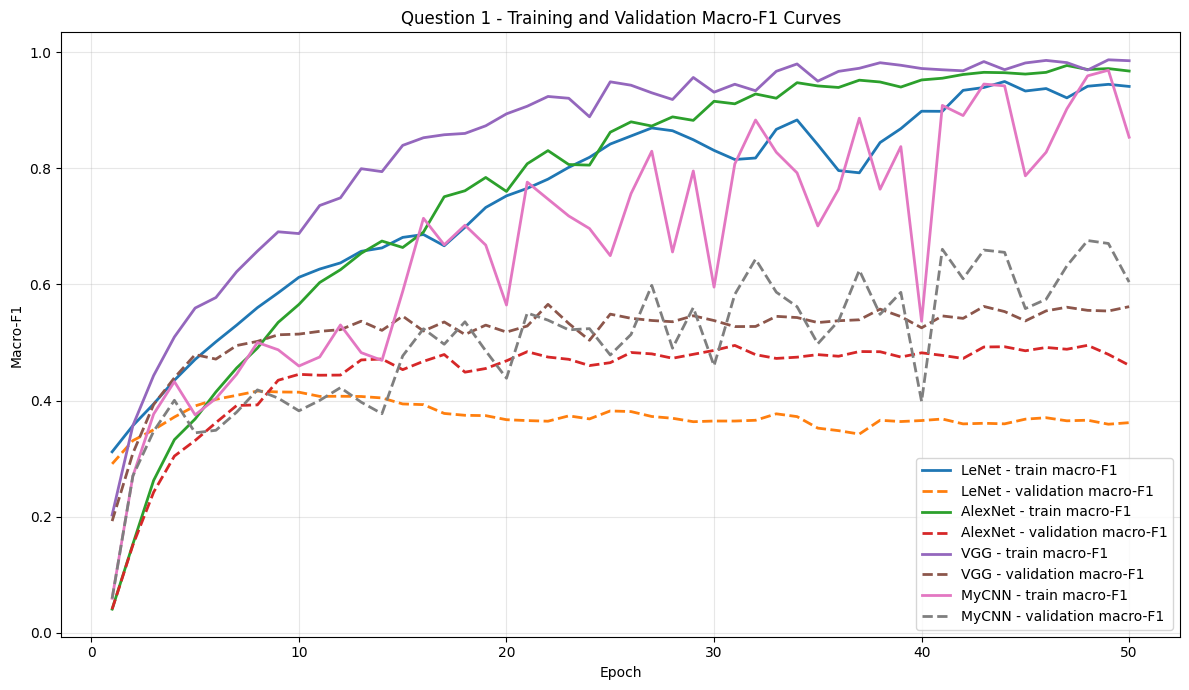

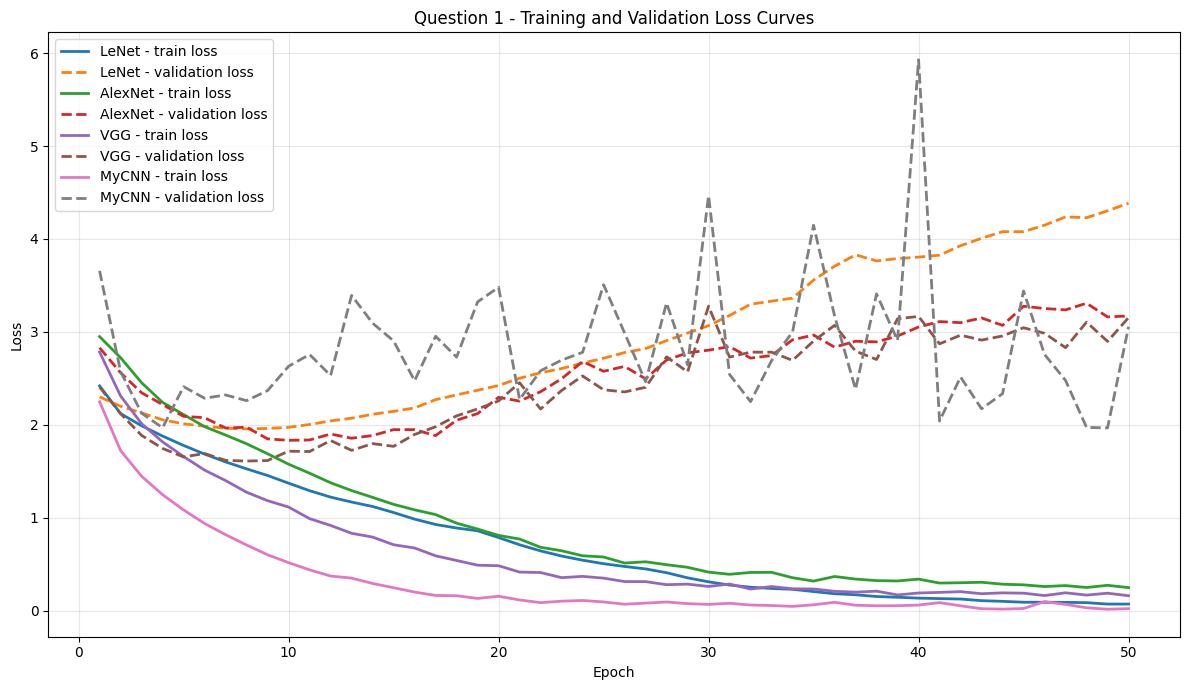

Final Question 1 comparison table:


,model,parameters,optimizer,loss,batch_size,epochs,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,MyCNN,307444,adam,kullback_leibler_divergence,32,50,0.853605,0.604090,0.675618,2.904709,0.6205,0.630899,0.630899
1,VGG,816692,adam,kullback_leibler_divergence,32,50,0.985421,0.561723,0.565727,2.976681,0.5815,0.575712,0.575712
2,AlexNet,2038932,adam,kullback_leibler_divergence,32,50,0.967629,0.460724,0.495116,3.127445,0.5085,0.501579,0.501579
3,LeNet,83976,adam,kullback_leibler_divergence,32,50,0.941098,0.361871,0.416306,4.086772,0.3805,0.377988,0.377988


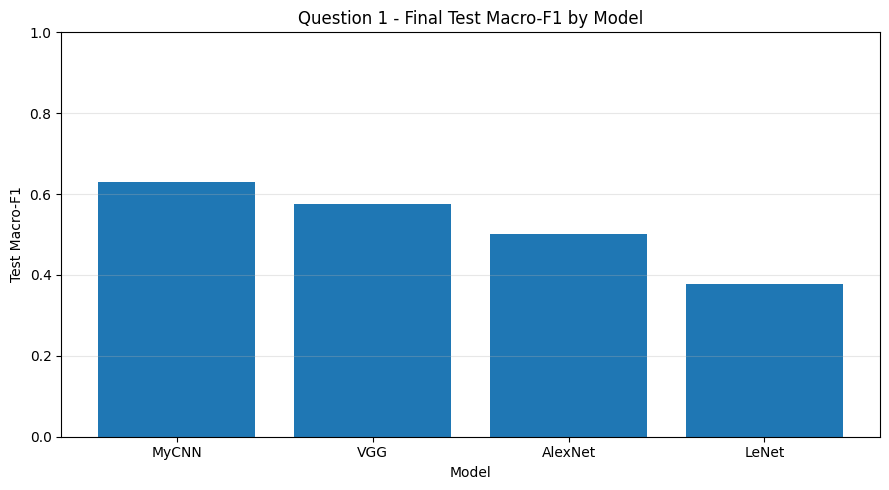

Final common configuration used for all four models:
  Optimizer:  adam
  Loss:       kullback_leibler_divergence
  Batch size: 32
  Epochs:     50

Best model by test macro-F1:
  MyCNN (test macro-F1 = 0.6309, test accuracy = 0.6205)


In [ ]:
# ============================================================
# Question 1 - Cell 3
# F1-score plots and final test-set evaluation
# ============================================================

# -----------------------------
# Plot training and validation F1-score curves
# -----------------------------

plt.figure(figsize=(12, 7))

for model_name, history_pack in final_histories.items():
    epochs_axis = np.arange(1, len(history_pack["val_macro_f1"]) + 1)

    plt.plot(
        epochs_axis,
        history_pack["train_macro_f1"],
        label=f"{model_name} - train macro-F1",
        linewidth=2,
    )

    plt.plot(
        epochs_axis,
        history_pack["val_macro_f1"],
        linestyle="--",
        label=f"{model_name} - validation macro-F1",
        linewidth=2,
    )

plt.title("Question 1 - Training and Validation Macro-F1 Curves")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Optional loss curves
# -----------------------------

plt.figure(figsize=(12, 7))

for model_name, history_pack in final_histories.items():
    history = history_pack["history"]
    epochs_axis = np.arange(1, len(history["loss"]) + 1)

    plt.plot(
        epochs_axis,
        history["loss"],
        label=f"{model_name} - train loss",
        linewidth=2,
    )

    plt.plot(
        epochs_axis,
        history["val_loss"],
        linestyle="--",
        label=f"{model_name} - validation loss",
        linewidth=2,
    )

plt.title("Question 1 - Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Final validation and test evaluation
# -----------------------------

q1_final_results = []

for model_name, model in final_models.items():
    history_pack = final_histories[model_name]
    loss_name = history_pack["loss_name"]

    test_metrics = evaluate_model(
        model=model,
        loss_name=loss_name,
        batch_size=EVAL_BATCH_SIZE,
    )

    best_val_macro_f1 = float(np.max(history_pack["val_macro_f1"]))
    final_val_macro_f1 = float(history_pack["val_macro_f1"][-1])
    final_train_macro_f1 = float(history_pack["train_macro_f1"][-1])

    result = {
        "model": model_name,
        "parameters": int(model.count_params()),
        "optimizer": history_pack["optimizer_name"],
        "loss": history_pack["loss_name"],
        "batch_size": int(history_pack["batch_size"]),
        "epochs": int(history_pack["epochs"]),
        "final_train_macro_f1": final_train_macro_f1,
        "final_val_macro_f1": final_val_macro_f1,
        "best_val_macro_f1": best_val_macro_f1,
        **test_metrics,
    }

    q1_final_results.append(result)

q1_final_results_df = (
    pd.DataFrame(q1_final_results)
    .sort_values("test_macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("Final Question 1 comparison table:")
display(q1_final_results_df)


# -----------------------------
# Compact ranking plot
# -----------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    q1_final_results_df["model"],
    q1_final_results_df["test_macro_f1"],
)

plt.title("Question 1 - Final Test Macro-F1 by Model")
plt.xlabel("Model")
plt.ylabel("Test Macro-F1")
plt.ylim(0, max(1.0, q1_final_results_df["test_macro_f1"].max() + 0.05))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Print selected configuration again for traceability
# -----------------------------

print("Final common configuration used for all four models:")
print(f"  Optimizer:  {BEST_OPTIMIZER}")
print(f"  Loss:       {BEST_LOSS}")
print(f"  Batch size: {BEST_BATCH_SIZE}")
print(f"  Epochs:     {FINAL_EPOCHS}")

print("\nBest model by test macro-F1:")
best_model_row = q1_final_results_df.iloc[0]
print(
    f"  {best_model_row['model']} "
    f"(test macro-F1 = {best_model_row['test_macro_f1']:.4f}, "
    f"test accuracy = {best_model_row['test_accuracy']:.4f})"
)

## **Question 1: Results and Comments**
---

In Question 1, four convolutional models were trained and compared on the same selected **20-class CIFAR-100 subset**:

- `LeNet`
- `AlexNet`
- `VGG`
- `MyCNN`

The full hyperparameter search was completed successfully:

$$
4 \text{ models} \times 4 \text{ optimizers} \times 4 \text{ losses} \times 4 \text{ batch sizes} = 256 \text{ runs}
$$

All 256 runs finished without failures. The best common configuration, selected by the **average validation macro-$F_1$ score across all four models**, was:

| Hyperparameter | Selected value |
|---|---|
| Optimizer | `Adam` |
| Loss | `kullback_leibler_divergence` |
| Batch size | `32` |
| Final training epochs | `50` |

Since the models use a `Dense(20, activation="softmax")` output layer, the problem is treated as a 20-class image-classification task. The use of `kullback_leibler_divergence` is valid here because the corresponding labels are represented as one-hot class distributions.

---

### **Final test-set comparison**

The final test results were:

| Model | Parameters | Test Accuracy | Test Macro-$F_1$ | Test Weighted-$F_1$ |
|---|---:|---:|---:|---:|
| `MyCNN` | 307,444 | 0.6205 | **0.6309** | **0.6309** |
| `VGG` | 816,692 | 0.5815 | 0.5757 | 0.5757 |
| `AlexNet` | 2,038,932 | 0.5085 | 0.5016 | 0.5016 |
| `LeNet` | 83,976 | 0.3805 | 0.3780 | 0.3780 |

The best model is therefore **`MyCNN`**, with:

$$
\text{test macro-}F_1 = 0.6309
$$

and:

$$
\text{test accuracy} = 0.6205
$$

The ranking of the models is:

$$
\text{MyCNN} > \text{VGG} > \text{AlexNet} > \text{LeNet}
$$

This ranking is reasonable when the theory and the dataset are considered together.

---

### **Interpretation of the model behavior**

`LeNet` has the smallest number of parameters and was originally designed for simpler handwritten digit recognition tasks. It uses a shallow architecture and therefore has limited representational capacity for natural RGB images such as CIFAR-100. Although it eventually reaches a high training macro-$F_1$, its validation and test scores remain much lower, which means that it does not learn features that generalize well to this more complex dataset.

`AlexNet` is much larger and deeper than `LeNet`, and historically it was designed for ImageNet-scale classification. However, in this experiment it is trained from scratch on a relatively small 20-class CIFAR-100 subset. Its parameter count is the largest among the four models, with more than 2 million trainable parameters. The curves show that its training macro-$F_1$ becomes very high, while the validation macro-$F_1$ remains much lower. This indicates strong overfitting: the model has enough capacity to fit the training set, but the available data and the absence of additional regularization in Question 1 are not sufficient for equally strong generalization.

`VGG` performs better than `AlexNet`. This agrees with the main architectural idea of VGG: instead of relying on very large early filters, VGG-style networks use repeated small $3 \times 3$ convolutional filters to build deeper hierarchical image features. This design is more suitable for visual feature extraction and gives better test performance than AlexNet in this experiment. However, VGG still overfits clearly, since its final training macro-$F_1$ is close to 1.0, while its validation and test macro-$F_1$ remain around 0.56-0.58.

`MyCNN` gives the best overall result. Unlike the adapted historical architectures, it is designed specifically for CIFAR-sized images. It uses small $3 \times 3$ convolutions, progressively increasing feature depth, Batch Normalization, Max Pooling, and Global Average Pooling. This gives it enough capacity to learn useful visual representations while keeping the parameter count moderate. In particular, `MyCNN` has fewer parameters than VGG and far fewer than AlexNet, but achieves the highest test macro-$F_1$. This suggests that its architecture provides a better balance between expressive power and generalization for this dataset.

---

### **Training and validation curves**

The macro-$F_1$ curves show that all models improve on the training set during the 50 epochs. However, the gap between training and validation performance differs significantly across models.

The strongest overfitting appears in `LeNet`, `AlexNet`, and `VGG`. Their training macro-$F_1$ scores become very high, but their validation macro-$F_1$ scores plateau much earlier and remain substantially lower. This behavior is also visible in the loss curves: the training losses continue to decrease, while the validation losses increase or fluctuate after the early epochs. This is a typical sign that the models are fitting the training data more strongly than the underlying generalizable patterns.

`MyCNN` also shows some overfitting, but it generalizes better than the other models. Its validation macro-$F_1$ reaches the highest values among the four models, and its final test macro-$F_1$ is the best. The validation curve is noisier than the training curve, but this is expected because macro-$F_1$ is computed class-wise and is more sensitive to per-class fluctuations than accuracy, especially on a smaller validation set.

---

### **Conclusion**

The results confirm that simply using a deeper or larger historical architecture is not necessarily optimal for a small CIFAR-style dataset. `AlexNet` and `VGG` were originally designed for large-scale ImageNet classification, while `LeNet` was designed for much simpler digit images. After adapting them to $32 \times 32 \times 3$ inputs, they can still learn meaningful features, but they either lack capacity for this dataset (`LeNet`) or overfit strongly when trained from scratch (`AlexNet`, `VGG`).

The custom `MyCNN` architecture is the best fit for this part of the assignment. It is compact, uses modern CNN design choices, and achieves the highest test macro-$F_1$ and accuracy. Therefore, `MyCNN` is selected as the most promising baseline for the regularization experiments in Question 2, where dropout and data augmentation are studied to further control overfitting.

## **Question 2: Assignment**
---

### **Step 1: Overfitting control**

For your own model, `MyCNN`, and **only for this model**, test different combinations of the following techniques for controlling **overfitting**, so that the model can **generalize** better:

- `Dropout` ([Dropout](https://www.tensorflow.org/tutorials/images/classification#dropout))

- **Data augmentation** ([Data augmentation](https://www.tensorflow.org/tutorials/images/classification#data_augmentation), [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator#class_imagedatagenerator))

---

### **Step 2: Evaluation**

Evaluate your results based on the $F_1$-score for the **validation set** and the **test set**.


## **Bootstrap Cell: Reloading the Selected Question 1 Configuration**
---

This cell is used when the notebook is opened in a new Colab runtime and we want to continue with Question 2 without rerunning the full Question 1 grid search.

Question 2 depends on the best common training configuration selected in Question 1:

- optimizer,
- loss function,
- batch size.

Since the full Question 1 grid search was saved to `q1_grid_results.csv`, we can reload the saved grid results and recompute the best common configuration directly from the CSV.

The selection logic is the same as in Question 1:

1. Keep only successful grid-search runs.
2. Group the results by common configuration:

$$
\text{optimizer} + \text{loss} + \text{batch size}
$$

3. For each configuration, compute the mean validation macro-$F_1$ across the four models:

- `LeNet`
- `AlexNet`
- `VGG`
- `MyCNN`

4. Select the configuration with the highest mean validation macro-$F_1$.

The test set is not used here. This cell only restores the selected training setup so that Question 2 can continue consistently.

In [ ]:
# ============================================================
# Bootstrap selected Q1 configuration from saved local grid CSV
# Use this in a new/runtime-resumed session before running Q2
# ============================================================

from pathlib import Path
import pandas as pd

# Try the most likely local paths first.
candidate_paths = [
    Path("q1_grid_results.csv"),
    Path("/content/q1_grid_results.csv"),
    Path("IVTA_Lab2/q1_grid_results.csv"),
]

# Also support Drive if it exists, but do not require it.
candidate_paths.append(Path("/content/drive/MyDrive/IVTA_Lab2/q1_grid_results.csv"))

Q1_GRID_RESULTS_PATH = None

for candidate_path in candidate_paths:
    if candidate_path.exists():
        Q1_GRID_RESULTS_PATH = candidate_path
        break

# If not found in the common locations, search the current workspace.
if Q1_GRID_RESULTS_PATH is None:
    search_roots = [
        Path.cwd(),
        Path("/content") if Path("/content").exists() else Path.cwd(),
    ]

    found_paths = []

    for root in search_roots:
        try:
            found_paths.extend(list(root.rglob("q1_grid_results.csv")))
        except Exception:
            pass

    if found_paths:
        Q1_GRID_RESULTS_PATH = found_paths[0]

if Q1_GRID_RESULTS_PATH is None:
    raise FileNotFoundError(
        "Could not find q1_grid_results.csv in the local Colab/runtime filesystem. "
        "If the runtime was replaced, the local CSV may have been lost. "
        "In that case, upload q1_grid_results.csv manually or rerun the Q1 grid."
    )

print(f"Loading Q1 grid results from: {Q1_GRID_RESULTS_PATH}")

q1_grid_results_df = pd.read_csv(Q1_GRID_RESULTS_PATH)

q1_grid_results_df = (
    q1_grid_results_df
    .drop_duplicates(
        subset=["model", "optimizer", "loss", "batch_size"],
        keep="last",
    )
    .reset_index(drop=True)
)

print(f"Loaded Q1 grid rows: {len(q1_grid_results_df)}")

q1_successful_grid_df = q1_grid_results_df[
    q1_grid_results_df["status"] == "ok"
].copy()

if len(q1_successful_grid_df) == 0:
    raise RuntimeError("No successful Q1 grid runs found in q1_grid_results.csv.")

expected_model_count = len(MODEL_BUILDERS) if "MODEL_BUILDERS" in globals() else 4

q1_config_summary_df = (
    q1_successful_grid_df
    .groupby(["optimizer", "loss", "batch_size"], as_index=False)
    .agg(
        mean_val_macro_f1=("val_macro_f1", "mean"),
        std_val_macro_f1=("val_macro_f1", "std"),
        min_val_macro_f1=("val_macro_f1", "min"),
        max_val_macro_f1=("val_macro_f1", "max"),
        model_count=("model", "nunique"),
    )
)

q1_config_summary_df = q1_config_summary_df[
    q1_config_summary_df["model_count"] == expected_model_count
].copy()

q1_config_summary_df = q1_config_summary_df.sort_values(
    ["mean_val_macro_f1", "min_val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

if len(q1_config_summary_df) == 0:
    raise RuntimeError(
        "No complete Q1 configuration found. "
        f"Expected each configuration to have {expected_model_count} models."
    )

best_config = q1_config_summary_df.iloc[0]

BEST_OPTIMIZER = best_config["optimizer"]
BEST_LOSS = best_config["loss"]
BEST_BATCH_SIZE = int(best_config["batch_size"])

print("Loaded selected Q1 configuration:")
print(f"  Optimizer:  {BEST_OPTIMIZER}")
print(f"  Loss:       {BEST_LOSS}")
print(f"  Batch size: {BEST_BATCH_SIZE}")
print(f"  Mean validation macro-F1: {best_config['mean_val_macro_f1']:.4f}")

display(q1_config_summary_df.head(10))

Loading Q1 grid results from: q1_grid_results.csv
Loaded Q1 grid rows: 256
Loaded selected Q1 configuration:
  Optimizer:  adam
  Loss:       kullback_leibler_divergence
  Batch size: 32
  Mean validation macro-F1: 0.3556


,optimizer,loss,batch_size,mean_val_macro_f1,std_val_macro_f1,min_val_macro_f1,max_val_macro_f1,model_count
0,adam,kullback_leibler_divergence,32,0.355599,0.064071,0.261806,0.401073,4
1,rmsprop,kullback_leibler_divergence,32,0.347934,0.042576,0.288687,0.389878,4
2,rmsprop,categorical_crossentropy,32,0.344831,0.036741,0.315594,0.398615,4
3,adam,sparse_categorical_crossentropy,32,0.338222,0.055300,0.298956,0.418245,4
4,adamw,kullback_leibler_divergence,32,0.334047,0.070503,0.230779,0.389580,4
5,adam,categorical_crossentropy,32,0.326990,0.058030,0.255088,0.386563,4
6,sgd_momentum,categorical_crossentropy,32,0.310516,0.084758,0.200731,0.388419,4
7,rmsprop,sparse_categorical_crossentropy,32,0.305660,0.074300,0.235638,0.382751,4
8,sgd_momentum,sparse_categorical_crossentropy,32,0.294664,0.074303,0.201528,0.377690,4
9,sgd_momentum,kullback_leibler_divergence,32,0.284302,0.076175,0.181833,0.365625,4


## **Question 2: Implementation Notes - MyCNN Regularization Grid**
---

Question 2 focuses only on `MyCNN`. The goal is to study how overfitting can be controlled using:

- dropout,
- data augmentation,
- the combination of dropout and data augmentation.

We keep the optimizer, loss function, and batch size fixed to the best common configuration selected in Question 1. This ensures that Question 2 studies the effect of regularization methods, not the effect of changing the whole training setup.

The regularization grid is:

| Parameter | Values |
|---|---|
| Dropout rate | `0.0`, `0.2`, `0.3`, `0.4`, `0.5` |
| Augmentation level | `none`, `light`, `medium`, `strong` |

This gives:

$$
5 \times 4 = 20
$$

short grid-search training runs.

The baseline case is:

$$
\text{dropout} = 0.0,\quad \text{augmentation} = \text{"none"}
$$

`MyCNN` keeps the same convolutional backbone as in Question 1: three convolutional blocks with 32, 64, and 128 filters. Dropout is applied only after the dense classifier layer, because dropout is mainly used to regularize the classifier part of the network. Data augmentation is applied only during training and is automatically disabled during validation and testing.

In [ ]:
# ============================================================
# Question 2 - Cell 1
# Setup, MyCNN regularization variants, and helper functions
# Memory-safer / resumable version
# ============================================================

import gc
import time
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models as keras_models
from sklearn.metrics import f1_score, accuracy_score
from IPython.display import display
from tqdm.auto import tqdm


# -----------------------------
# Dependency check from Question 1
# -----------------------------

required_q1_objects = [
    "BEST_OPTIMIZER",
    "BEST_LOSS",
    "BEST_BATCH_SIZE",
    "NUM_CLASSES",
    "INPUT_SHAPE",
    "x_train",
    "x_val",
    "x_test",
    "y_train_int",
    "y_val_int",
    "y_test_int",
    "labels_for_loss",
    "compile_model",
    "set_global_seed",
    "stable_seed",
]

missing_q1_objects = [
    name for name in required_q1_objects
    if name not in globals()
]

if missing_q1_objects:
    raise RuntimeError(
        "Question 2 depends on Question 1 setup and selected hyperparameters. "
        f"Missing objects: {missing_q1_objects}. "
        "Run Question 1 Cell 1 and Cell 2 first, including the final selection of "
        "BEST_OPTIMIZER, BEST_LOSS, and BEST_BATCH_SIZE."
    )


# -----------------------------
# Q2 constants
# -----------------------------

Q2_GRID_EPOCHS = 10
Q2_FINAL_EPOCHS = 50

Q2_DROPOUT_GRID = [
    0.0,
    0.2,
    0.3,
    0.4,
    0.5,
]

Q2_AUGMENTATION_GRID = [
    "none",
    "light",
    "medium",
    "strong",
]

Q2_EXPECTED_GRID_RUNS = (
    len(Q2_DROPOUT_GRID)
    * len(Q2_AUGMENTATION_GRID)
)

assert Q2_EXPECTED_GRID_RUNS == 20, (
    f"Expected 20 Q2 grid runs, got {Q2_EXPECTED_GRID_RUNS}."
)

Q2_GRID_RESULTS_PATH = Path("q2_grid_results.csv")
Q2_FINAL_RESULTS_PATH = Path("q2_final_results.csv")
Q2_FINAL_HISTORY_PATH = Path("q2_final_history.csv")

# Safer Colab mode:
# - 5 means: run 5 Q2 grid model-runs per execution of Cell 2, save, then rerun Cell 2.
# - None means: try all remaining Q2 grid runs in one execution.
Q2_GRID_CHUNK_SIZE = 5

print("Question 2 uses the selected Question 1 configuration:")
print(f"  Optimizer:  {BEST_OPTIMIZER}")
print(f"  Loss:       {BEST_LOSS}")
print(f"  Batch size: {BEST_BATCH_SIZE}")
print()
print("Q2 dropout grid:", Q2_DROPOUT_GRID)
print("Q2 augmentation grid:", Q2_AUGMENTATION_GRID)
print("Expected Q2 grid runs:", Q2_EXPECTED_GRID_RUNS)
print("Q2 grid results CSV:", Q2_GRID_RESULTS_PATH)
print("Q2 final results CSV:", Q2_FINAL_RESULTS_PATH)
print("Q2 final history CSV:", Q2_FINAL_HISTORY_PATH)
print("Q2 grid chunk size:", Q2_GRID_CHUNK_SIZE)


# -----------------------------
# Augmentation factory
# -----------------------------

def make_q2_augmentation(augmentation_name):
    """
    Return a fresh Keras augmentation pipeline.

    The augmentation layers are active only during training. During validation,
    prediction, and testing, they are inactive automatically.
    """
    if augmentation_name == "none":
        return None

    if augmentation_name == "light":
        return tf.keras.Sequential(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomTranslation(0.05, 0.05),
            ],
            name="augmentation_light",
        )

    if augmentation_name == "medium":
        return tf.keras.Sequential(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomTranslation(0.10, 0.10),
                layers.RandomRotation(0.05),
                layers.RandomZoom(0.10),
            ],
            name="augmentation_medium",
        )

    if augmentation_name == "strong":
        return tf.keras.Sequential(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomTranslation(0.15, 0.15),
                layers.RandomRotation(0.08),
                layers.RandomZoom(0.15),
                layers.RandomContrast(0.10),
            ],
            name="augmentation_strong",
        )

    raise ValueError(f"Unknown augmentation level: {augmentation_name}")


# -----------------------------
# Regularized MyCNN builder
# -----------------------------

def q2_conv_bn_relu(x, filters, kernel_size=3):
    """
    Convolution + Batch Normalization + ReLU block.
    Same core block idea as the baseline MyCNN from Question 1.
    """
    x = layers.Conv2D(
        filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x


def build_q2_mycnn(
    dropout_rate=0.0,
    augmentation_name="none",
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
):
    """
    MyCNN with optional data augmentation and optional dropout.

    The convolutional backbone is kept the same as in Question 1:
    - Block 1: 32 filters
    - Block 2: 64 filters
    - Block 3: 128 filters

    Dropout is applied after Dense(128, ReLU), not inside the convolutional
    feature extractor, to keep the comparison simple and interpretable.
    """
    inputs = layers.Input(shape=input_shape)

    augmentation = make_q2_augmentation(augmentation_name)

    if augmentation is not None:
        x = augmentation(inputs)
    else:
        x = inputs

    x = q2_conv_bn_relu(x, 32)
    x = q2_conv_bn_relu(x, 32)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = q2_conv_bn_relu(x, 64)
    x = q2_conv_bn_relu(x, 64)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = q2_conv_bn_relu(x, 128)
    x = q2_conv_bn_relu(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)

    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model_name = f"MyCNN_dropout_{dropout_rate:.1f}_aug_{augmentation_name}"

    return keras_models.Model(
        inputs=inputs,
        outputs=outputs,
        name=model_name,
    )


# -----------------------------
# Batched prediction and metrics
# -----------------------------

def q2_predict_probabilities_batched(model, x_data, batch_size=256):
    """
    Memory-safer prediction helper.

    Uses direct model calls instead of model.predict() to reduce retracing noise
    during repeated training/evaluation runs.
    """
    probabilities = []

    for start_idx in range(0, len(x_data), batch_size):
        end_idx = start_idx + batch_size
        batch = x_data[start_idx:end_idx]
        batch_prob = model(batch, training=False).numpy()
        probabilities.append(batch_prob)

    return np.concatenate(probabilities, axis=0)


def q2_validation_macro_f1(model):
    """
    Compute validation macro-F1 for a trained model.
    """
    val_prob = q2_predict_probabilities_batched(
        model=model,
        x_data=x_val,
        batch_size=256,
    )
    val_pred = np.argmax(val_prob, axis=1)

    return float(
        f1_score(
            y_val_int,
            val_pred,
            average="macro",
            zero_division=0,
        )
    )


def q2_test_metrics(model, loss_name=BEST_LOSS):
    """
    Evaluate a trained Q2 model on the test set.
    """
    y_test_fit = labels_for_loss(loss_name, "test")

    evaluation = model.evaluate(
        x_test,
        y_test_fit,
        batch_size=256,
        verbose=0,
        return_dict=True,
    )

    test_prob = q2_predict_probabilities_batched(
        model=model,
        x_data=x_test,
        batch_size=256,
    )
    test_pred = np.argmax(test_prob, axis=1)

    return {
        "test_loss": float(evaluation["loss"]),
        "test_accuracy": float(accuracy_score(y_test_int, test_pred)),
        "test_macro_f1": float(
            f1_score(
                y_test_int,
                test_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "test_weighted_f1": float(
            f1_score(
                y_test_int,
                test_pred,
                average="weighted",
                zero_division=0,
            )
        ),
    }


# -----------------------------
# Q2 grid training helper
# -----------------------------

def run_q2_grid_model(
    dropout_rate,
    augmentation_name,
    epochs=Q2_GRID_EPOCHS,
):
    """
    Train one MyCNN regularization configuration for a short grid-search run.
    """
    tf.keras.backend.clear_session()
    gc.collect()

    run_seed = stable_seed(
        "q2_grid",
        dropout_rate,
        augmentation_name,
        BEST_OPTIMIZER,
        BEST_LOSS,
        BEST_BATCH_SIZE,
        epochs,
    )
    set_global_seed(run_seed)

    start_time = time.time()

    model = None
    history = None
    val_macro_f1 = np.nan

    try:
        model = build_q2_mycnn(
            dropout_rate=dropout_rate,
            augmentation_name=augmentation_name,
        )

        parameter_count = int(model.count_params())

        compile_model(
            model=model,
            optimizer_name=BEST_OPTIMIZER,
            loss_name=BEST_LOSS,
        )

        y_train_fit = labels_for_loss(BEST_LOSS, "train")
        y_val_fit = labels_for_loss(BEST_LOSS, "val")

        history = model.fit(
            x_train,
            y_train_fit,
            validation_data=(x_val, y_val_fit),
            epochs=epochs,
            batch_size=BEST_BATCH_SIZE,
            verbose=0,
            callbacks=[
                tf.keras.callbacks.TerminateOnNaN(),
            ],
        )

        val_macro_f1 = q2_validation_macro_f1(model)

        result = {
            "status": "ok",
            "dropout_rate": float(dropout_rate),
            "augmentation": augmentation_name,
            "epochs": int(epochs),
            "optimizer": BEST_OPTIMIZER,
            "loss": BEST_LOSS,
            "batch_size": int(BEST_BATCH_SIZE),
            "parameters": parameter_count,
            "train_loss_last": float(history.history["loss"][-1]),
            "val_loss_last": float(history.history["val_loss"][-1]),
            "val_macro_f1": float(val_macro_f1),
            "duration_sec": float(time.time() - start_time),
            "error": "",
        }

    except Exception as exc:
        result = {
            "status": "failed",
            "dropout_rate": float(dropout_rate),
            "augmentation": augmentation_name,
            "epochs": int(epochs),
            "optimizer": BEST_OPTIMIZER,
            "loss": BEST_LOSS,
            "batch_size": int(BEST_BATCH_SIZE),
            "parameters": np.nan,
            "train_loss_last": np.nan,
            "val_loss_last": np.nan,
            "val_macro_f1": np.nan,
            "duration_sec": float(time.time() - start_time),
            "error": repr(exc),
        }

    finally:
        del history

        if model is not None:
            del model

        tf.keras.backend.clear_session()
        gc.collect()

    return result


# -----------------------------
# Q2 final-training F1 callback
# -----------------------------

class Q2MacroF1Callback(tf.keras.callbacks.Callback):
    """
    Computes train and validation macro-F1 after each final-training epoch.
    """

    def __init__(self):
        super().__init__()
        self.train_macro_f1 = []
        self.val_macro_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_prob = q2_predict_probabilities_batched(
            model=self.model,
            x_data=x_train,
            batch_size=256,
        )
        train_pred = np.argmax(train_prob, axis=1)

        val_prob = q2_predict_probabilities_batched(
            model=self.model,
            x_data=x_val,
            batch_size=256,
        )
        val_pred = np.argmax(val_prob, axis=1)

        train_f1 = f1_score(
            y_train_int,
            train_pred,
            average="macro",
            zero_division=0,
        )

        val_f1 = f1_score(
            y_val_int,
            val_pred,
            average="macro",
            zero_division=0,
        )

        self.train_macro_f1.append(float(train_f1))
        self.val_macro_f1.append(float(val_f1))

        logs["macro_f1"] = float(train_f1)
        logs["val_macro_f1"] = float(val_f1)


# -----------------------------
# Q2 final training and immediate evaluation helper
# -----------------------------

def train_and_evaluate_q2_final_model(
    variant_name,
    dropout_rate,
    augmentation_name,
    grid_val_macro_f1,
    epochs=Q2_FINAL_EPOCHS,
):
    """
    Train one selected Q2 variant from scratch for 50 epochs, evaluate it
    immediately on the test set, then return only the history and result rows.

    The trained model object is deleted before returning to reduce RAM use.
    """
    tf.keras.backend.clear_session()
    gc.collect()

    run_seed = stable_seed(
        "q2_final",
        variant_name,
        dropout_rate,
        augmentation_name,
        BEST_OPTIMIZER,
        BEST_LOSS,
        BEST_BATCH_SIZE,
    )
    set_global_seed(run_seed)

    model = None
    history = None

    try:
        model = build_q2_mycnn(
            dropout_rate=dropout_rate,
            augmentation_name=augmentation_name,
        )

        parameter_count = int(model.count_params())

        compile_model(
            model=model,
            optimizer_name=BEST_OPTIMIZER,
            loss_name=BEST_LOSS,
        )

        y_train_fit = labels_for_loss(BEST_LOSS, "train")
        y_val_fit = labels_for_loss(BEST_LOSS, "val")

        f1_callback = Q2MacroF1Callback()

        history = model.fit(
            x_train,
            y_train_fit,
            validation_data=(x_val, y_val_fit),
            epochs=epochs,
            batch_size=BEST_BATCH_SIZE,
            verbose=1,
            callbacks=[
                f1_callback,
                tf.keras.callbacks.TerminateOnNaN(),
            ],
        )

        test_metrics = q2_test_metrics(
            model=model,
            loss_name=BEST_LOSS,
        )

        history_dict = history.history
        n_epochs_completed = len(history_dict["loss"])

        final_train_macro_f1 = float(f1_callback.train_macro_f1[-1])
        final_val_macro_f1 = float(f1_callback.val_macro_f1[-1])
        best_val_macro_f1 = float(np.max(f1_callback.val_macro_f1))
        overfitting_gap = final_train_macro_f1 - final_val_macro_f1

        result_row = {
            "variant": variant_name,
            "dropout_rate": float(dropout_rate),
            "augmentation": augmentation_name,
            "parameters": parameter_count,
            "optimizer": BEST_OPTIMIZER,
            "loss": BEST_LOSS,
            "batch_size": int(BEST_BATCH_SIZE),
            "epochs": int(n_epochs_completed),
            "grid_val_macro_f1": float(grid_val_macro_f1),
            "final_train_macro_f1": final_train_macro_f1,
            "final_val_macro_f1": final_val_macro_f1,
            "best_val_macro_f1": best_val_macro_f1,
            "overfitting_gap": float(overfitting_gap),
            **test_metrics,
        }

        history_rows = []

        for epoch_idx in range(n_epochs_completed):
            row = {
                "variant": variant_name,
                "dropout_rate": float(dropout_rate),
                "augmentation": augmentation_name,
                "epoch": int(epoch_idx + 1),
                "loss": float(history_dict["loss"][epoch_idx]),
                "val_loss": float(history_dict["val_loss"][epoch_idx]),
                "train_macro_f1": float(f1_callback.train_macro_f1[epoch_idx]),
                "val_macro_f1": float(f1_callback.val_macro_f1[epoch_idx]),
            }

            if "accuracy" in history_dict:
                row["accuracy"] = float(history_dict["accuracy"][epoch_idx])

            if "val_accuracy" in history_dict:
                row["val_accuracy"] = float(history_dict["val_accuracy"][epoch_idx])

            history_rows.append(row)

        history_df = pd.DataFrame(history_rows)

        return result_row, history_df

    finally:
        del history

        if model is not None:
            del model

        tf.keras.backend.clear_session()
        gc.collect()

Question 2 uses the selected Question 1 configuration:
  Optimizer:  adam
  Loss:       kullback_leibler_divergence
  Batch size: 32

Q2 dropout grid: [0.0, 0.2, 0.3, 0.4, 0.5]
Q2 augmentation grid: ['none', 'light', 'medium', 'strong']
Expected Q2 grid runs: 20
Q2 grid results CSV: q2_grid_results.csv
Q2 final results CSV: q2_final_results.csv
Q2 final history CSV: q2_final_history.csv
Q2 grid chunk size: 5


## **Question 2: Implementation Notes - Regularization Grid Search and Final Training**
---

This cell runs the 20-configuration regularization grid for `MyCNN`.

Each grid run trains a fresh `MyCNN` for a short number of epochs using one dropout/augmentation combination. The validation macro-$F_1$ score is used to choose the strongest regularization settings.

After the grid search, we select representative final models:

- the baseline model with no dropout and no augmentation,
- the best dropout-only model,
- the best augmentation-only model,
- the best combined dropout + augmentation model,
- the overall best grid configuration, if it is not already included.

Each selected model is then trained again from scratch for **50 epochs** using the best optimizer/loss/batch-size configuration selected in Question 1.

In [ ]:
# ============================================================
# Question 2 - Cell 2
# Resumable 20-run regularization grid and final Q2 training
# ============================================================

# -----------------------------
# Build full Q2 grid specification
# -----------------------------

q2_full_grid = []

for dropout_rate in Q2_DROPOUT_GRID:
    for augmentation_name in Q2_AUGMENTATION_GRID:
        q2_full_grid.append(
            {
                "dropout_rate": float(dropout_rate),
                "augmentation": str(augmentation_name),
            }
        )

assert len(q2_full_grid) == Q2_EXPECTED_GRID_RUNS, (
    f"Expected {Q2_EXPECTED_GRID_RUNS} Q2 grid rows, got {len(q2_full_grid)}."
)


# -----------------------------
# Load previous Q2 grid results, if available
# -----------------------------

if Q2_GRID_RESULTS_PATH.exists():
    q2_grid_results_df = pd.read_csv(Q2_GRID_RESULTS_PATH)

    print(f"Loaded existing Q2 grid results from: {Q2_GRID_RESULTS_PATH}")
    print(f"Existing rows before duplicate cleanup: {len(q2_grid_results_df)}")

    q2_grid_results_df = (
        q2_grid_results_df
        .drop_duplicates(
            subset=["dropout_rate", "augmentation"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q2_grid_results_df.to_csv(Q2_GRID_RESULTS_PATH, index=False)

    print(f"Existing rows after duplicate cleanup: {len(q2_grid_results_df)}")
else:
    q2_grid_results_df = pd.DataFrame()
    print("No existing Q2 grid results found. Starting from scratch.")


def q2_grid_key(row_or_dict):
    """
    Unique key for one Q2 grid model-run.
    """
    return (
        float(row_or_dict["dropout_rate"]),
        str(row_or_dict["augmentation"]),
    )


completed_q2_keys = set()

if len(q2_grid_results_df) > 0:
    for _, row in q2_grid_results_df.iterrows():
        completed_q2_keys.add(q2_grid_key(row))

remaining_q2_grid_all = [
    config for config in q2_full_grid
    if q2_grid_key(config) not in completed_q2_keys
]

if Q2_GRID_CHUNK_SIZE is None:
    remaining_q2_grid_this_run = remaining_q2_grid_all
else:
    remaining_q2_grid_this_run = remaining_q2_grid_all[:Q2_GRID_CHUNK_SIZE]

print(f"Completed Q2 grid runs: {len(completed_q2_keys)} / {Q2_EXPECTED_GRID_RUNS}")
print(f"Remaining Q2 grid runs total: {len(remaining_q2_grid_all)}")
print(f"Q2 grid runs scheduled in this execution: {len(remaining_q2_grid_this_run)}")


# -----------------------------
# Run scheduled Q2 grid configurations
# -----------------------------

if len(remaining_q2_grid_this_run) > 0:
    q2_progress_bar = tqdm(
        total=len(remaining_q2_grid_this_run),
        desc="Q2 MyCNN regularization grid - current chunk",
        unit="run",
    )

    q2_grid_start_time = time.time()

    for config in remaining_q2_grid_this_run:
        dropout_rate = float(config["dropout_rate"])
        augmentation_name = str(config["augmentation"])

        q2_progress_bar.set_postfix(
            {
                "dropout": dropout_rate,
                "augmentation": augmentation_name,
            }
        )

        result = run_q2_grid_model(
            dropout_rate=dropout_rate,
            augmentation_name=augmentation_name,
            epochs=Q2_GRID_EPOCHS,
        )

        result_df = pd.DataFrame([result])

        # Save immediately after every run.
        if Q2_GRID_RESULTS_PATH.exists():
            result_df.to_csv(
                Q2_GRID_RESULTS_PATH,
                mode="a",
                header=False,
                index=False,
            )
        else:
            result_df.to_csv(
                Q2_GRID_RESULTS_PATH,
                index=False,
            )

        q2_progress_bar.update(1)

        tf.keras.backend.clear_session()
        gc.collect()

    q2_progress_bar.close()

    q2_grid_duration_min = (time.time() - q2_grid_start_time) / 60.0
    print(f"Current Q2 grid chunk completed in {q2_grid_duration_min:.2f} minutes.")
else:
    print("No Q2 grid runs scheduled because the Q2 grid is already complete.")


# -----------------------------
# Reload full saved Q2 grid results
# -----------------------------

if Q2_GRID_RESULTS_PATH.exists():
    q2_grid_results_df = pd.read_csv(Q2_GRID_RESULTS_PATH)

    q2_grid_results_df = (
        q2_grid_results_df
        .drop_duplicates(
            subset=["dropout_rate", "augmentation"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q2_grid_results_df.to_csv(Q2_GRID_RESULTS_PATH, index=False)
else:
    q2_grid_results_df = pd.DataFrame()

print(f"Total saved Q2 grid model-runs: {len(q2_grid_results_df)} / {Q2_EXPECTED_GRID_RUNS}")

if len(q2_grid_results_df) > 0:
    print(f"Successful runs: {(q2_grid_results_df['status'] == 'ok').sum()}")
    print(f"Failed runs: {(q2_grid_results_df['status'] == 'failed').sum()}")

    print("Top saved Q2 grid runs so far:")
    display(
        q2_grid_results_df
        .sort_values("val_macro_f1", ascending=False)
        .head(20)
    )


# -----------------------------
# Stop here if the full Q2 grid is not complete yet
# -----------------------------

if len(q2_grid_results_df) < Q2_EXPECTED_GRID_RUNS:
    print("\nQ2 grid search is not complete yet.")
    print(
        f"Saved {len(q2_grid_results_df)} / {Q2_EXPECTED_GRID_RUNS} runs. "
        "Rerun this same cell to continue from the saved CSV."
    )
    print("Final Q2 variant selection and 50-epoch training will start automatically once all 20 runs are saved.")

else:
    print("\nFull 20-run Q2 regularization grid is complete.")

    # -----------------------------
    # Inspect failed runs, if any
    # -----------------------------

    q2_failed_grid_runs_df = q2_grid_results_df[
        q2_grid_results_df["status"] == "failed"
    ].copy()

    if len(q2_failed_grid_runs_df) > 0:
        print("Some Q2 grid runs failed. They are shown below.")
        display(
            q2_failed_grid_runs_df[
                ["dropout_rate", "augmentation", "error"]
            ]
        )
    else:
        print("All Q2 grid runs completed successfully.")


    # -----------------------------
    # Select representative final variants
    # -----------------------------

    q2_successful_grid_df = q2_grid_results_df[
        q2_grid_results_df["status"] == "ok"
    ].copy()

    if len(q2_successful_grid_df) == 0:
        raise RuntimeError("No successful Q2 grid runs found.")

    q2_successful_grid_df = q2_successful_grid_df.sort_values(
        "val_macro_f1",
        ascending=False,
    ).reset_index(drop=True)


    def q2_best_row(condition, description):
        """
        Select the best grid row satisfying a condition.
        """
        subset = q2_successful_grid_df[condition].copy()

        if len(subset) == 0:
            raise RuntimeError(f"No Q2 grid result found for: {description}")

        return subset.sort_values("val_macro_f1", ascending=False).iloc[0]


    q2_baseline_row = q2_best_row(
        (q2_successful_grid_df["dropout_rate"] == 0.0)
        & (q2_successful_grid_df["augmentation"] == "none"),
        "baseline",
    )

    q2_best_dropout_only_row = q2_best_row(
        (q2_successful_grid_df["dropout_rate"] > 0.0)
        & (q2_successful_grid_df["augmentation"] == "none"),
        "dropout only",
    )

    q2_best_augmentation_only_row = q2_best_row(
        (q2_successful_grid_df["dropout_rate"] == 0.0)
        & (q2_successful_grid_df["augmentation"] != "none"),
        "augmentation only",
    )

    q2_best_combined_row = q2_best_row(
        (q2_successful_grid_df["dropout_rate"] > 0.0)
        & (q2_successful_grid_df["augmentation"] != "none"),
        "dropout + augmentation",
    )

    q2_best_overall_row = q2_successful_grid_df.iloc[0]


    def q2_config_key_from_row(row):
        """
        Unique key for a dropout/augmentation configuration.
        """
        return (
            float(row["dropout_rate"]),
            str(row["augmentation"]),
        )


    q2_selected_variant_rows = OrderedDict()

    candidate_rows = [
        ("MyCNN_Baseline", q2_baseline_row),
        ("MyCNN_Best_Dropout_Only", q2_best_dropout_only_row),
        ("MyCNN_Best_Augmentation_Only", q2_best_augmentation_only_row),
        ("MyCNN_Best_Dropout_Augmentation", q2_best_combined_row),
        ("MyCNN_Best_Overall", q2_best_overall_row),
    ]

    seen_config_keys = set()

    for variant_name, row in candidate_rows:
        key = q2_config_key_from_row(row)

        if key not in seen_config_keys:
            q2_selected_variant_rows[variant_name] = row
            seen_config_keys.add(key)

    print("Selected Q2 variants for final 50-epoch training:")

    q2_selected_summary = []

    for variant_name, row in q2_selected_variant_rows.items():
        q2_selected_summary.append(
            {
                "variant": variant_name,
                "dropout_rate": float(row["dropout_rate"]),
                "augmentation": str(row["augmentation"]),
                "grid_val_macro_f1": float(row["val_macro_f1"]),
                "grid_val_loss": float(row["val_loss_last"]),
            }
        )

    q2_selected_summary_df = pd.DataFrame(q2_selected_summary)
    display(q2_selected_summary_df)


    # -----------------------------
    # Load previous final results, if available
    # -----------------------------

    selected_variant_names = list(q2_selected_variant_rows.keys())

    if Q2_FINAL_RESULTS_PATH.exists():
        q2_final_results_df = pd.read_csv(Q2_FINAL_RESULTS_PATH)

        q2_final_results_df = (
            q2_final_results_df
            .drop_duplicates(
                subset=["variant"],
                keep="last",
            )
            .reset_index(drop=True)
        )
    else:
        q2_final_results_df = pd.DataFrame()

    if Q2_FINAL_HISTORY_PATH.exists():
        q2_final_history_df = pd.read_csv(Q2_FINAL_HISTORY_PATH)

        q2_final_history_df = (
            q2_final_history_df
            .drop_duplicates(
                subset=["variant", "epoch"],
                keep="last",
            )
            .reset_index(drop=True)
        )
    else:
        q2_final_history_df = pd.DataFrame()

    completed_final_variants = set()

    if len(q2_final_results_df) > 0:
        completed_final_variants = set(
            q2_final_results_df["variant"].astype(str).tolist()
        )

    remaining_final_variants = [
        variant_name for variant_name in selected_variant_names
        if variant_name not in completed_final_variants
    ]

    print(f"Completed Q2 final variants: {len(completed_final_variants)}")
    print(f"Remaining Q2 final variants: {len(remaining_final_variants)}")


    # -----------------------------
    # Final 50-epoch training and immediate evaluation
    # -----------------------------

    q2_final_training_start_time = time.time()

    for variant_name in remaining_final_variants:
        row = q2_selected_variant_rows[variant_name]

        dropout_rate = float(row["dropout_rate"])
        augmentation_name = str(row["augmentation"])
        grid_val_macro_f1 = float(row["val_macro_f1"])

        print("\n" + "=" * 80)
        print(f"Q2 final training: {variant_name}")
        print(f"Dropout rate: {dropout_rate}")
        print(f"Augmentation:  {augmentation_name}")
        print("=" * 80)

        result_row, history_df = train_and_evaluate_q2_final_model(
            variant_name=variant_name,
            dropout_rate=dropout_rate,
            augmentation_name=augmentation_name,
            grid_val_macro_f1=grid_val_macro_f1,
            epochs=Q2_FINAL_EPOCHS,
        )

        result_df = pd.DataFrame([result_row])

        if Q2_FINAL_RESULTS_PATH.exists():
            result_df.to_csv(
                Q2_FINAL_RESULTS_PATH,
                mode="a",
                header=False,
                index=False,
            )
        else:
            result_df.to_csv(
                Q2_FINAL_RESULTS_PATH,
                index=False,
            )

        if Q2_FINAL_HISTORY_PATH.exists():
            history_df.to_csv(
                Q2_FINAL_HISTORY_PATH,
                mode="a",
                header=False,
                index=False,
            )
        else:
            history_df.to_csv(
                Q2_FINAL_HISTORY_PATH,
                index=False,
            )

        tf.keras.backend.clear_session()
        gc.collect()

    q2_final_training_duration_min = (
        time.time() - q2_final_training_start_time
    ) / 60.0

    print("\nQ2 final training work for this execution completed.")
    print(f"Q2 final training duration in this execution: {q2_final_training_duration_min:.2f} minutes.")


    # -----------------------------
    # Reload final saved results and histories
    # -----------------------------

    q2_final_results_df = pd.read_csv(Q2_FINAL_RESULTS_PATH)

    q2_final_results_df = (
        q2_final_results_df
        .drop_duplicates(
            subset=["variant"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q2_final_results_df = q2_final_results_df[
        q2_final_results_df["variant"].isin(selected_variant_names)
    ].copy()

    q2_final_results_df = q2_final_results_df.sort_values(
        "test_macro_f1",
        ascending=False,
    ).reset_index(drop=True)

    q2_final_results_df.to_csv(Q2_FINAL_RESULTS_PATH, index=False)

    q2_final_history_df = pd.read_csv(Q2_FINAL_HISTORY_PATH)

    q2_final_history_df = (
        q2_final_history_df
        .drop_duplicates(
            subset=["variant", "epoch"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q2_final_history_df = q2_final_history_df[
        q2_final_history_df["variant"].isin(selected_variant_names)
    ].copy()

    q2_final_history_df = q2_final_history_df.sort_values(
        ["variant", "epoch"],
        ascending=True,
    ).reset_index(drop=True)

    q2_final_history_df.to_csv(Q2_FINAL_HISTORY_PATH, index=False)

    print("Final Question 2 comparison table:")
    display(q2_final_results_df)

    print("Q2 final history rows saved:", len(q2_final_history_df))

Loaded existing Q2 grid results from: q2_grid_results.csv
Existing rows before duplicate cleanup: 15
Existing rows after duplicate cleanup: 15
Completed Q2 grid runs: 15 / 20
Remaining Q2 grid runs total: 5
Q2 grid runs scheduled in this execution: 5


Q2 MyCNN regularization grid - current chunk:   0%|          | 0/5 [00:00<?, ?run/s]

Current Q2 grid chunk completed in 5.76 minutes.
Total saved Q2 grid model-runs: 20 / 20
Successful runs: 20
Failed runs: 0
Top saved Q2 grid runs so far:


,status,dropout_rate,augmentation,epochs,optimizer,loss,batch_size,parameters,train_loss_last,val_loss_last,val_macro_f1,duration_sec,error
10,ok,0.3,medium,10,adam,kullback_leibler_divergence,32,307444,1.249498,1.388156,0.580927,55.180482,NaN
4,ok,0.2,none,10,adam,kullback_leibler_divergence,32,307444,0.634894,1.586726,0.559865,32.066597,NaN
16,ok,0.5,none,10,adam,kullback_leibler_divergence,32,307444,0.929854,1.428826,0.548492,36.020478,NaN
12,ok,0.4,none,10,adam,kullback_leibler_divergence,32,307444,0.765553,1.688709,0.524374,31.382161,NaN
14,ok,0.4,medium,10,adam,kullback_leibler_divergence,32,307444,1.316984,1.524391,0.514978,56.952960,NaN
17,ok,0.5,light,10,adam,kullback_leibler_divergence,32,307444,1.219527,1.585396,0.511421,74.318717,NaN
5,ok,0.2,light,10,adam,kullback_leibler_divergence,32,307444,0.951563,1.635842,0.505018,51.509944,NaN
1,ok,0.0,light,10,adam,kullback_leibler_divergence,32,307444,0.835709,1.887382,0.498027,55.280066,NaN
7,ok,0.2,strong,10,adam,kullback_leibler_divergence,32,307444,1.389083,1.610985,0.493395,60.864721,NaN
11,ok,0.3,strong,10,adam,kullback_leibler_divergence,32,307444,1.429550,1.595493,0.493217,58.930377,NaN



Full 20-run Q2 regularization grid is complete.
All Q2 grid runs completed successfully.
Selected Q2 variants for final 50-epoch training:


,variant,dropout_rate,augmentation,grid_val_macro_f1,grid_val_loss
0,MyCNN_Baseline,0.0,none,0.481223,2.403258
1,MyCNN_Best_Dropout_Only,0.2,none,0.559865,1.586726
2,MyCNN_Best_Augmentation_Only,0.0,light,0.498027,1.887382
3,MyCNN_Best_Dropout_Augmentation,0.3,medium,0.580927,1.388156


Completed Q2 final variants: 0
Remaining Q2 final variants: 4

Q2 final training: MyCNN_Baseline
Dropout rate: 0.0
Augmentation:  none
Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.3158 - loss: 2.2313 - val_accuracy: 0.1060 - val_loss: 4.0616 - macro_f1: 0.0426 - val_macro_f1: 0.0376
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4511 - loss: 1.7554 - val_accuracy: 0.3807 - val_loss: 2.1542 - macro_f1: 0.3548 - val_macro_f1: 0.3491
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5334 - loss: 1.4758 - val_accuracy: 0.4680 - val_loss: 1.8045 - macro_f1: 0.4643 - val_macro_f1: 0.4264
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5985 - loss: 1.2633 - val_accuracy: 0.5173 - val_loss: 1.6819 - macro_f1: 0.5298 - val_macro_f1: 0.4744
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6580 - loss: 1.0841 - val_accuracy: 0.4960 - val_loss: 1.7110 - macro_f1: 0.5362 - val_macro_f1: 0.4652
Epoch 6/5

,variant,dropout_rate,augmentation,parameters,optimizer,loss,batch_size,epochs,grid_val_macro_f1,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,overfitting_gap,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,MyCNN_Best_Dropout_Augmentation,0.3,medium,307444,adam,kullback_leibler_divergence,32,50,0.580927,0.761852,0.653625,0.672992,0.108227,1.489040,0.6595,0.660666,0.660666
1,MyCNN_Baseline,0.0,none,307444,adam,kullback_leibler_divergence,32,50,0.481223,0.925142,0.644144,0.665591,0.280997,2.138416,0.6560,0.659643,0.659643
2,MyCNN_Best_Augmentation_Only,0.0,light,307444,adam,kullback_leibler_divergence,32,50,0.498027,0.793318,0.654963,0.673670,0.138354,1.716800,0.6645,0.654434,0.654434
3,MyCNN_Best_Dropout_Only,0.2,none,307444,adam,kullback_leibler_divergence,32,50,0.559865,0.772748,0.552872,0.663857,0.219876,2.976762,0.5765,0.569779,0.569779


Q2 final history rows saved: 200


## **Question 2: Implementation Notes - Regularization Plots and Test Evaluation**
---

This cell evaluates the final Question 2 models.

First, it plots the training and validation macro-$F_1$ curves. These curves show whether dropout and/or data augmentation reduce overfitting. A large gap between training and validation macro-$F_1$ indicates overfitting, while a smaller gap usually indicates better generalization.

Then, the selected models are evaluated on the test set using:

- test loss,
- test accuracy,
- test macro-$F_1$,
- test weighted-$F_1$.

The main comparison metric remains macro-$F_1$, because all 20 selected classes should contribute equally to the evaluation.

Loaded Q2 final results:


,variant,dropout_rate,augmentation,parameters,optimizer,loss,batch_size,epochs,grid_val_macro_f1,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,overfitting_gap,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,MyCNN_Best_Dropout_Augmentation,0.3,medium,307444,adam,kullback_leibler_divergence,32,50,0.580927,0.761852,0.653625,0.672992,0.108227,1.489040,0.6595,0.660666,0.660666
1,MyCNN_Baseline,0.0,none,307444,adam,kullback_leibler_divergence,32,50,0.481223,0.925142,0.644144,0.665591,0.280997,2.138416,0.6560,0.659643,0.659643
2,MyCNN_Best_Augmentation_Only,0.0,light,307444,adam,kullback_leibler_divergence,32,50,0.498027,0.793318,0.654963,0.673670,0.138354,1.716800,0.6645,0.654434,0.654434
3,MyCNN_Best_Dropout_Only,0.2,none,307444,adam,kullback_leibler_divergence,32,50,0.559865,0.772748,0.552872,0.663857,0.219876,2.976762,0.5765,0.569779,0.569779


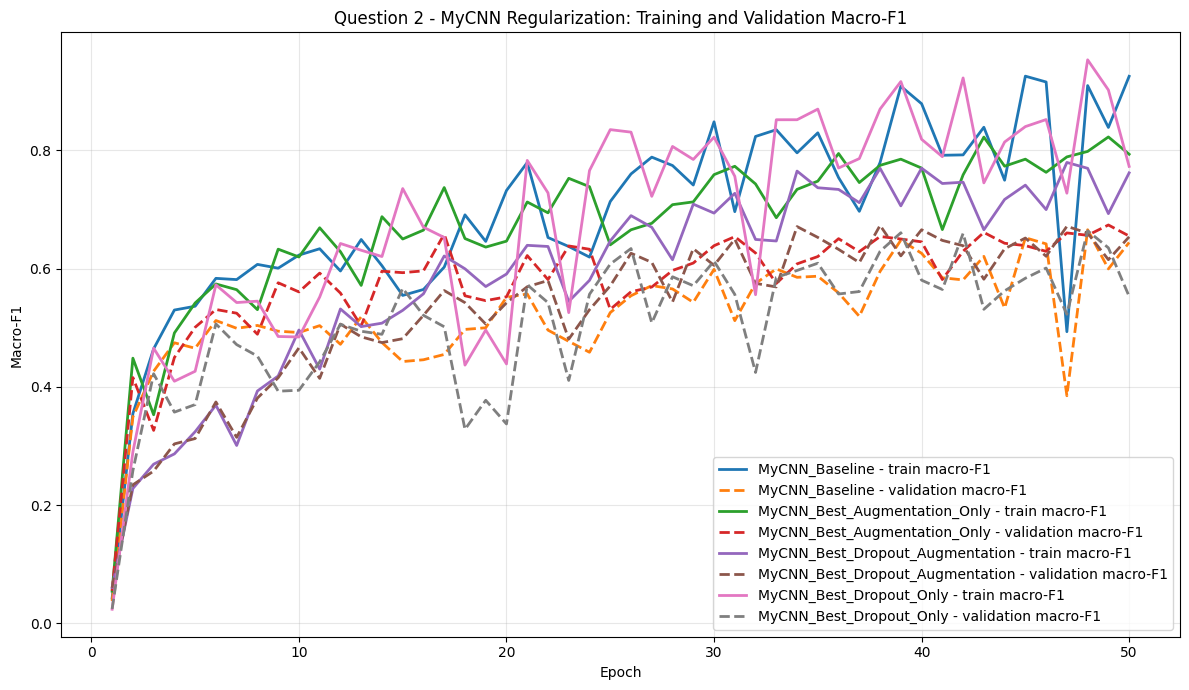

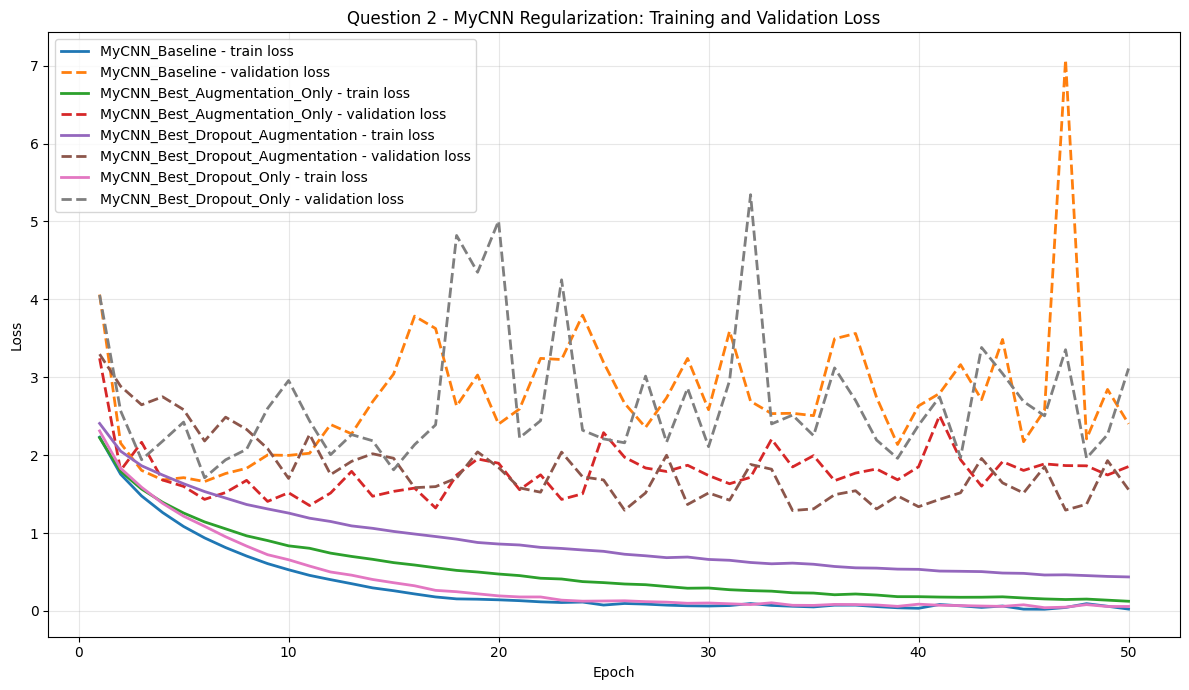

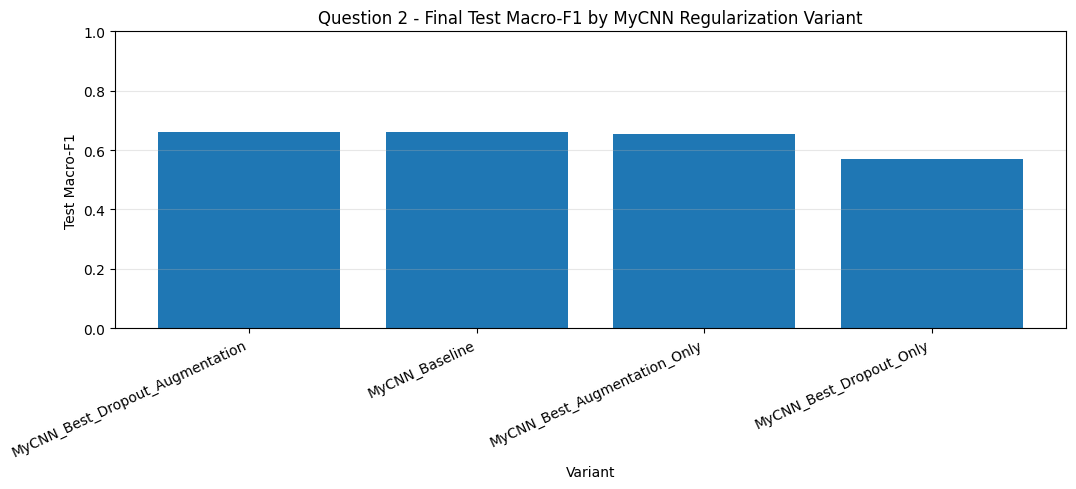

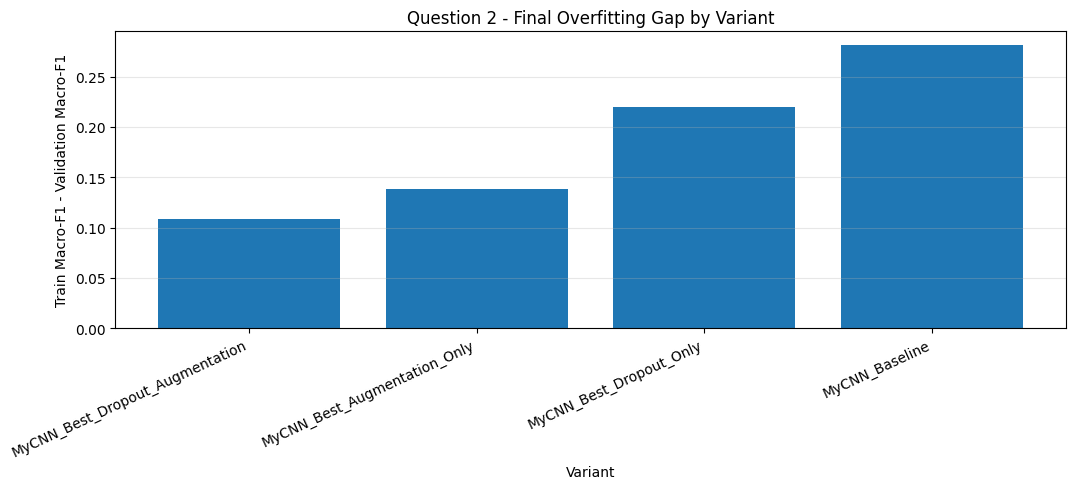

Question 2 used the Question 1 selected training setup:
  Optimizer:  adam
  Loss:       kullback_leibler_divergence
  Batch size: 32
  Final epochs per selected variant: 50

Best Q2 model by test macro-F1:
  MyCNN_Best_Dropout_Augmentation (dropout = 0.3, augmentation = medium, test macro-F1 = 0.6607, test accuracy = 0.6595)


In [ ]:
# ============================================================
# Question 2 - Cell 3
# Regularization plots and final test-set evaluation
# Memory-safer version using saved histories/results
# ============================================================

# -----------------------------
# Load final Q2 results and histories if needed
# -----------------------------

if "q2_final_results_df" not in globals():
    if not Q2_FINAL_RESULTS_PATH.exists():
        raise RuntimeError(
            f"Missing {Q2_FINAL_RESULTS_PATH}. Run Q2 Cell 2 until final training is complete."
        )

    q2_final_results_df = pd.read_csv(Q2_FINAL_RESULTS_PATH)

if "q2_final_history_df" not in globals():
    if not Q2_FINAL_HISTORY_PATH.exists():
        raise RuntimeError(
            f"Missing {Q2_FINAL_HISTORY_PATH}. Run Q2 Cell 2 until final training is complete."
        )

    q2_final_history_df = pd.read_csv(Q2_FINAL_HISTORY_PATH)

q2_final_results_df = q2_final_results_df.sort_values(
    "test_macro_f1",
    ascending=False,
).reset_index(drop=True)

q2_final_history_df = q2_final_history_df.sort_values(
    ["variant", "epoch"],
    ascending=True,
).reset_index(drop=True)

print("Loaded Q2 final results:")
display(q2_final_results_df)


# -----------------------------
# Plot training and validation macro-F1 curves
# -----------------------------

plt.figure(figsize=(12, 7))

for variant_name in q2_final_history_df["variant"].unique():
    variant_history = q2_final_history_df[
        q2_final_history_df["variant"] == variant_name
    ].copy()

    plt.plot(
        variant_history["epoch"],
        variant_history["train_macro_f1"],
        label=f"{variant_name} - train macro-F1",
        linewidth=2,
    )

    plt.plot(
        variant_history["epoch"],
        variant_history["val_macro_f1"],
        linestyle="--",
        label=f"{variant_name} - validation macro-F1",
        linewidth=2,
    )

plt.title("Question 2 - MyCNN Regularization: Training and Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Plot training and validation loss curves
# -----------------------------

plt.figure(figsize=(12, 7))

for variant_name in q2_final_history_df["variant"].unique():
    variant_history = q2_final_history_df[
        q2_final_history_df["variant"] == variant_name
    ].copy()

    plt.plot(
        variant_history["epoch"],
        variant_history["loss"],
        label=f"{variant_name} - train loss",
        linewidth=2,
    )

    plt.plot(
        variant_history["epoch"],
        variant_history["val_loss"],
        linestyle="--",
        label=f"{variant_name} - validation loss",
        linewidth=2,
    )

plt.title("Question 2 - MyCNN Regularization: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Test macro-F1 ranking plot
# -----------------------------

plt.figure(figsize=(11, 5))

plt.bar(
    q2_final_results_df["variant"],
    q2_final_results_df["test_macro_f1"],
)

plt.title("Question 2 - Final Test Macro-F1 by MyCNN Regularization Variant")
plt.xlabel("Variant")
plt.ylabel("Test Macro-F1")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, max(1.0, q2_final_results_df["test_macro_f1"].max() + 0.05))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Overfitting gap plot
# -----------------------------

q2_gap_df = q2_final_results_df.sort_values(
    "overfitting_gap",
    ascending=True,
).reset_index(drop=True)

plt.figure(figsize=(11, 5))

plt.bar(
    q2_gap_df["variant"],
    q2_gap_df["overfitting_gap"],
)

plt.title("Question 2 - Final Overfitting Gap by Variant")
plt.xlabel("Variant")
plt.ylabel("Train Macro-F1 - Validation Macro-F1")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Traceability summary
# -----------------------------

print("Question 2 used the Question 1 selected training setup:")
print(f"  Optimizer:  {BEST_OPTIMIZER}")
print(f"  Loss:       {BEST_LOSS}")
print(f"  Batch size: {BEST_BATCH_SIZE}")
print(f"  Final epochs per selected variant: {Q2_FINAL_EPOCHS}")

print("\nBest Q2 model by test macro-F1:")
q2_best_row = q2_final_results_df.iloc[0]

print(
    f"  {q2_best_row['variant']} "
    f"(dropout = {q2_best_row['dropout_rate']}, "
    f"augmentation = {q2_best_row['augmentation']}, "
    f"test macro-F1 = {q2_best_row['test_macro_f1']:.4f}, "
    f"test accuracy = {q2_best_row['test_accuracy']:.4f})"
)

## **Question 2: Results and Comments**
---

Question 2 focuses only on the custom `MyCNN` architecture from Question 1. The goal is not to compare different CNN families, but to study how **regularization** affects the generalization ability of the same model.

The training setup was kept fixed to the best common configuration selected in Question 1:

| Hyperparameter | Value |
|---|---|
| Optimizer | `Adam` |
| Loss | `kullback_leibler_divergence` |
| Batch size | `32` |
| Final training epochs | `50` |

The regularization grid tested:

$$
5 \text{ dropout values} \times 4 \text{ augmentation levels} = 20 \text{ runs}
$$

The tested dropout values were:

$$
0.0,\ 0.2,\ 0.3,\ 0.4,\ 0.5
$$

and the augmentation levels were:

$$
\text{none},\ \text{light},\ \text{medium},\ \text{strong}
$$

After the grid search, the selected representative variants were retrained from scratch for 50 epochs and evaluated on the test set.

---

### **Final test-set comparison**

The final test results were:

| Variant | Dropout | Augmentation | Test Accuracy | Test Macro-$F_1$ | Test Weighted-$F_1$ | Overfitting Gap |
|---|---:|---|---:|---:|---:|---:|
| `MyCNN_Best_Dropout_Augmentation` | 0.3 | medium | 0.6595 | **0.6607** | **0.6607** | **0.1082** |
| `MyCNN_Baseline` | 0.0 | none | 0.6560 | 0.6596 | 0.6596 | 0.2810 |
| `MyCNN_Best_Augmentation_Only` | 0.0 | light | **0.6645** | 0.6544 | 0.6544 | 0.1384 |
| `MyCNN_Best_Dropout_Only` | 0.2 | none | 0.5765 | 0.5698 | 0.5698 | 0.2199 |

The best model by test macro-$F_1$ is:

$$
\text{MyCNN_Best_Dropout_Augmentation}
$$

with:

$$
\text{test macro-}F_1 = 0.6607
$$

This model uses:

$$
\text{dropout} = 0.3,\quad \text{augmentation} = \text{medium}
$$

Although the baseline has a very close test macro-$F_1$ score, the combined dropout and augmentation model is preferable because it achieves the best test macro-$F_1$ while also producing the smallest overfitting gap.

---

### **Effect of dropout and data augmentation**

The baseline `MyCNN` is trained without dropout and without data augmentation. Its final training macro-$F_1$ is very high, around 0.925, while its final validation macro-$F_1$ is around 0.644. This creates a large overfitting gap:

$$
0.9251 - 0.6441 = 0.2810
$$

This means that the model learns the training set very strongly, but a significant part of that performance does not transfer to unseen validation data. This behavior is also visible in the loss curves, where the training loss keeps decreasing while the validation loss becomes unstable and remains much higher.

The dropout-only model reduces the training score, as expected, because dropout randomly disables part of the dense representation during training. In theory, this should reduce co-adaptation between neurons and improve robustness. However, in this experiment, dropout alone does not give the best result. The selected dropout-only variant has a lower validation and test macro-$F_1$ than the baseline. This suggests that, for this specific architecture and dataset, dropout without augmentation may remove useful capacity without providing enough additional data diversity.

The augmentation-only model performs better. It uses label-preserving transformations to expose the model to more varied versions of the training images. This is directly connected to the role of augmentation in CNN training: the model should learn features that remain stable under small visual changes such as shifts, flips, rotations, and zooms. The augmentation-only variant reaches the highest test accuracy, 0.6645, and has a much smaller overfitting gap than the baseline:

$$
0.1384 \quad \text{instead of} \quad 0.2810
$$

This shows that augmentation improves generalization by making the effective training distribution richer.

The best overall behavior comes from combining dropout and augmentation. The combined model does not achieve the highest training macro-$F_1$, but this is not a problem. Its lower training score indicates stronger regularization. More importantly, its validation and test performance remain high, and its overfitting gap is the smallest among all selected variants:

$$
\text{overfitting gap} = 0.1082
$$

This is the most balanced result: the model is not simply memorizing the training set, but learning features that generalize better to unseen examples.

---

### **Interpretation of the curves**

The macro-$F_1$ curves show that the baseline reaches the highest training score among the selected variants. However, its validation curve remains clearly lower, which indicates overfitting.

The augmentation-only and combined dropout + augmentation variants have lower training macro-$F_1$ curves, but their validation curves are more competitive. This is the desired behavior in a regularization experiment: the goal is not to maximize training performance, but to improve validation and test performance.

The loss curves confirm the same conclusion. For the baseline, validation loss is noisy and can become very large, even though the training loss continues to decrease. This means that the model becomes increasingly confident on the training set, but that confidence does not always correspond to better validation predictions. The combined dropout + augmentation model has a more controlled behavior, with lower overfitting and better final test macro-$F_1$.

---

### **Conclusion**

Question 2 confirms that the main limitation of the baseline `MyCNN` is not lack of capacity, but overfitting. The model already has enough expressive power to learn the 20-class CIFAR-100 subset, but without regularization it fits the training data too strongly.

Data augmentation is more effective than dropout alone in this experiment, because it directly increases the diversity of the training images. Dropout alone is less successful, probably because the compact `MyCNN` architecture does not have excessive dense-layer capacity to remove. The best result is obtained when both methods are combined:

$$
\text{dropout} = 0.3,\quad \text{augmentation} = \text{medium}
$$

This variant achieves the best test macro-$F_1$ and the smallest overfitting gap. Therefore, the combined dropout + augmentation model is the best `MyCNN` regularized model from Question 2.

## **Question 3: Assignment**
---

### **Step 1: Transfer learning**

Apply **transfer learning** to your own model, `MyCNN`, specifically to the version that achieved the best $F_1$-score when addressing **overfitting**.

For transfer learning, use [`VGG19`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19) and [`EfficientNetB0`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet/EfficientNetB0) as pretrained models.

a. **Freeze** the convolutional base and train only the **classification head** by setting `trainable = False`.

b. Train only a **percentage of the layers** located closer to the network output. In this case, the `trainable` flags should be set **separately for each layer**.

---

### **Step 2: Evaluation**

Evaluate your results based on the $F_1$-score for the **validation set** and the **test set**.


## **Question 3: Implementation Notes - Transfer Learning Setup**
---

Question 3 applies **transfer learning** using two ImageNet-pretrained convolutional neural networks:

- `VGG19`
- `EfficientNetB0`

For both models, we use:

```python
include_top=False
weights="imagenet"
```

This means that the original ImageNet classifier is removed, and only the pretrained convolutional feature extractor is reused.

The original CIFAR-100 images have shape:

$$
32 \times 32 \times 3
$$

For transfer learning, they are resized to:

$$
128 \times 128 \times 3
$$

This resolution is larger than the original CIFAR-100 image size, so the pretrained models receive more spatial information. At the same time, it remains much lighter than the standard ImageNet input size:

$$
224 \times 224
$$

Each pretrained model receives its own preprocessing function:

| Model | Preprocessing Function |
|---|---|
| `VGG19` | `tf.keras.applications.vgg19.preprocess_input` |
| `EfficientNetB0` | `tf.keras.applications.efficientnet.preprocess_input` |

---

### **Custom Classification Head**

Because we use `include_top=False`, the original ImageNet classifier is removed. Therefore, we design and add our own classifier head for the 20-class CIFAR-100 subset.

The classification head added on top of each pretrained base is:

| Layer | Purpose |
|---|---|
| `GlobalAveragePooling2D` | Converts convolutional feature maps into a compact feature vector without creating a very large `Flatten` representation |
| `Dense(256, activation="relu")` | Learns a task-specific representation for the 20 selected classes |
| `Dropout(0.4)` | Reduces overfitting in the new classifier head |
| `Dense(20, activation="softmax")` | Outputs one probability per selected CIFAR-100 class |

This head is our own design choice. It was selected to be large enough to learn a useful mapping from ImageNet features to the 20 selected CIFAR-100 classes, but still compact enough to avoid excessive overfitting.

The final output layer has `20` units because the selected CIFAR-100 subset contains exactly 20 classes:

```python
Dense(20, activation="softmax")
```

---

### **Stage 1: Frozen-Base Training**

In the first stage, the pretrained convolutional base is frozen:

```python
base_model.trainable = False
```

Only the newly added classification head is trained.

This allows the model to learn how to map the pretrained ImageNet features to the selected CIFAR-100 classes without immediately modifying the pretrained convolutional weights.

The frozen-base stage uses:

```python
Adam(learning_rate=1e-3)
```

and is trained for:

$$
25 \text{ epochs}
$$

---

### **Stage 2: Fine-Tuning**

In the second stage, only the final layers of the pretrained base are unfrozen. These layers are closer to the network output and contain more task-specific, high-level visual features.

The trainable flags are set separately for each layer, as required. This ensures that we do not fine-tune the whole pretrained network blindly.

The fine-tuning strategy is:

| Model | Fine-Tuning Strategy |
|---|---|
| `VGG19` | Unfreeze only the final convolutional block, `block5_*` |
| `EfficientNetB0` | Unfreeze only the last 30 layers, while keeping Batch Normalization layers frozen |

For `VGG19`, this means only layers whose names start with:

```python
block5_
```

are made trainable.

For `EfficientNetB0`, all layers are first frozen, and then only the last 30 layers are considered for fine-tuning. Batch Normalization layers remain frozen because updating their statistics on a small dataset can make transfer learning unstable.

The fine-tuning stage uses a much smaller learning rate:

```python
Adam(learning_rate=1e-5)
```

This allows the model to slightly adapt the high-level pretrained features to the new classification task, while avoiding large updates that could destroy the useful ImageNet representations.

The fine-tuning stage is trained for:

$$
20 \text{ epochs}
$$

---

### **Final Training Schedule**

The selected training schedule is intentionally heavier:

$$
25 \text{ frozen epochs} + 20 \text{ fine-tuning epochs}
$$

Therefore, each transfer-learning model is trained for:

$$
45 \text{ total epochs}
$$

The goal is to compare whether fine-tuning improves validation and test macro-$F_1$ compared with using the frozen pretrained feature extractor only.

In [ ]:
# ============================================================
# Question 3 - Cell 1
# Transfer learning setup, datasets, model builders, and helpers
# ============================================================

import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models as keras_models
from sklearn.metrics import f1_score, accuracy_score
from IPython.display import display


# -----------------------------
# Reproducibility
# -----------------------------

SEED = 26

def q3_set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    try:
        tf.keras.utils.set_random_seed(seed)
    except Exception:
        pass


def q3_stable_seed(*parts, base_seed=SEED):
    text = "|".join(str(part) for part in parts)
    value = sum((idx + 1) * ord(char) for idx, char in enumerate(text))

    return int((base_seed + value) % 2_000_000_000)


q3_set_global_seed(SEED)


# -----------------------------
# Required data checks
# -----------------------------

required_data_objects = [
    "x_train",
    "x_val",
    "x_test",
    "NUM_CLASSES",
]

missing_data_objects = [
    name for name in required_data_objects
    if name not in globals()
]

if missing_data_objects:
    raise RuntimeError(
        f"Missing required data objects for Q3: {missing_data_objects}. "
        "Run the dataset preparation and label-remapping cells first."
    )

if "y_train_int" not in globals():
    y_train_int = np.asarray(y_train).reshape(-1).astype("int32")

if "y_val_int" not in globals():
    y_val_int = np.asarray(y_val).reshape(-1).astype("int32")

if "y_test_int" not in globals():
    y_test_int = np.asarray(y_test).reshape(-1).astype("int32")

x_train = x_train.astype("float32")
x_val = x_val.astype("float32")
x_test = x_test.astype("float32")

y_train_int = np.asarray(y_train_int).reshape(-1).astype("int32")
y_val_int = np.asarray(y_val_int).reshape(-1).astype("int32")
y_test_int = np.asarray(y_test_int).reshape(-1).astype("int32")

INPUT_SHAPE = tuple(x_train.shape[1:])

print("Q3 input data:")
print("  x_train:", x_train.shape, y_train_int.shape)
print("  x_val:  ", x_val.shape, y_val_int.shape)
print("  x_test: ", x_test.shape, y_test_int.shape)
print("  NUM_CLASSES:", NUM_CLASSES)


# -----------------------------
# Q3 constants
# -----------------------------

TRANSFER_INPUT_SIZE = 128
TRANSFER_BATCH_SIZE = 32

FROZEN_EPOCHS = 25
FINETUNE_EPOCHS = 20

FROZEN_LR = 1e-3
FINETUNE_LR = 1e-5

TRANSFER_DROPOUT_RATE = 0.4
TRANSFER_DENSE_UNITS = 256

EFFICIENTNET_FINETUNE_LAST_LAYERS = 30

# Set to None for full-train F1 computation.
# If runtime becomes too slow, set this to e.g. 2500.
TRANSFER_TRAIN_F1_SAMPLE_SIZE = None

Q3_OUTPUT_DIR = Path("q3_outputs")
Q3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Q3_RESULTS_PATH = Q3_OUTPUT_DIR / "q3_transfer_results.csv"
Q3_HISTORY_PATH = Q3_OUTPUT_DIR / "q3_transfer_history.csv"

print("\nQ3 transfer-learning setup:")
print("  Transfer input size:", TRANSFER_INPUT_SIZE)
print("  Transfer batch size:", TRANSFER_BATCH_SIZE)
print("  Frozen epochs:", FROZEN_EPOCHS)
print("  Fine-tuning epochs:", FINETUNE_EPOCHS)
print("  Frozen LR:", FROZEN_LR)
print("  Fine-tuning LR:", FINETUNE_LR)
print("  Output directory:", Q3_OUTPUT_DIR)


# -----------------------------
# Model-specific preprocessing
# -----------------------------

def q3_get_preprocess_function(model_name):
    if model_name == "VGG19":
        return tf.keras.applications.vgg19.preprocess_input

    if model_name == "EfficientNetB0":
        return tf.keras.applications.efficientnet.preprocess_input

    raise ValueError(f"Unknown transfer model: {model_name}")


def q3_preprocess_image(image, label, preprocess_fn):
    """
    Resize 32x32 CIFAR image to 128x128, convert from [0, 1] to [0, 255],
    then apply the model-specific ImageNet preprocessing.
    """
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(
        image,
        [TRANSFER_INPUT_SIZE, TRANSFER_INPUT_SIZE],
        method="bilinear",
    )

    # The previous preprocessing normalized CIFAR images to [0, 1].
    # Keras application preprocessing expects ImageNet-style image scale.
    image = image * 255.0
    image = preprocess_fn(image)

    label = tf.cast(label, tf.int32)

    return image, label


def make_q3_datasets(model_name):
    """
    Build tf.data datasets for a specific pretrained model.
    """
    preprocess_fn = q3_get_preprocess_function(model_name)
    autotune = tf.data.AUTOTUNE

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices((x_train, y_train_int))
        .shuffle(buffer_size=len(x_train), seed=SEED, reshuffle_each_iteration=True)
        .map(
            lambda image, label: q3_preprocess_image(image, label, preprocess_fn),
            num_parallel_calls=autotune,
        )
        .batch(TRANSFER_BATCH_SIZE)
        .prefetch(autotune)
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices((x_val, y_val_int))
        .map(
            lambda image, label: q3_preprocess_image(image, label, preprocess_fn),
            num_parallel_calls=autotune,
        )
        .batch(TRANSFER_BATCH_SIZE)
        .prefetch(autotune)
    )

    test_ds = (
        tf.data.Dataset
        .from_tensor_slices((x_test, y_test_int))
        .map(
            lambda image, label: q3_preprocess_image(image, label, preprocess_fn),
            num_parallel_calls=autotune,
        )
        .batch(TRANSFER_BATCH_SIZE)
        .prefetch(autotune)
    )

    if TRANSFER_TRAIN_F1_SAMPLE_SIZE is None:
        train_eval_x = x_train
        train_eval_y = y_train_int
    else:
        train_eval_x = x_train[:TRANSFER_TRAIN_F1_SAMPLE_SIZE]
        train_eval_y = y_train_int[:TRANSFER_TRAIN_F1_SAMPLE_SIZE]

    train_eval_ds = (
        tf.data.Dataset
        .from_tensor_slices((train_eval_x, train_eval_y))
        .map(
            lambda image, label: q3_preprocess_image(image, label, preprocess_fn),
            num_parallel_calls=autotune,
        )
        .batch(TRANSFER_BATCH_SIZE)
        .prefetch(autotune)
    )

    return train_ds, val_ds, test_ds, train_eval_ds


# -----------------------------
# Model builders
# -----------------------------

def build_q3_transfer_model(model_name):
    """
    Build a transfer-learning model with an ImageNet-pretrained base and
    a new 20-class classification head.
    """
    input_shape = (
        TRANSFER_INPUT_SIZE,
        TRANSFER_INPUT_SIZE,
        3,
    )

    if model_name == "VGG19":
        base_model = tf.keras.applications.VGG19(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape,
        )

    elif model_name == "EfficientNetB0":
        base_model = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape,
        )

    else:
        raise ValueError(f"Unknown transfer model: {model_name}")

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    # training=False keeps BatchNorm layers stable, especially for EfficientNet.
    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dense(
        TRANSFER_DENSE_UNITS,
        activation="relu",
        name="transfer_dense",
    )(x)
    x = layers.Dropout(
        TRANSFER_DROPOUT_RATE,
        name="transfer_dropout",
    )(x)
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="class_output",
    )(x)

    model = keras_models.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"{model_name}_transfer",
    )

    return model, base_model


def q3_get_base_model(model):
    """
    Retrieve the nested pretrained base model from the transfer model.
    """
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            if layer.name in ["vgg19", "efficientnetb0"]:
                return layer

    raise RuntimeError("Could not find nested pretrained base model.")


def q3_count_trainable_parameters(model):
    return int(
        np.sum(
            [
                np.prod(variable.shape)
                for variable in model.trainable_weights
            ]
        )
    )


def q3_count_non_trainable_parameters(model):
    return int(
        np.sum(
            [
                np.prod(variable.shape)
                for variable in model.non_trainable_weights
            ]
        )
    )


# -----------------------------
# Compile and fine-tuning helpers
# -----------------------------

def compile_q3_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )

    return model


def set_q3_frozen_base(model):
    base_model = q3_get_base_model(model)
    base_model.trainable = False

    return base_model


def set_q3_finetuning(model_name, model):
    """
    Unfreeze only the last part of the pretrained base.

    VGG19:
      - unfreeze block5 layers.

    EfficientNetB0:
      - unfreeze approximately the last 30 layers,
      - keep BatchNormalization layers frozen.
    """
    base_model = q3_get_base_model(model)
    base_model.trainable = True

    if model_name == "VGG19":
        for layer in base_model.layers:
            layer.trainable = layer.name.startswith("block5_")

    elif model_name == "EfficientNetB0":
        for layer in base_model.layers:
            layer.trainable = False

        for layer in base_model.layers[-EFFICIENTNET_FINETUNE_LAST_LAYERS:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

    else:
        raise ValueError(f"Unknown transfer model: {model_name}")

    return base_model


# -----------------------------
# F1 and evaluation helpers
# -----------------------------

def q3_predict_on_dataset(model, dataset):
    y_true_parts = []
    y_pred_parts = []

    for batch_images, batch_labels in dataset:
        batch_prob = model(batch_images, training=False).numpy()
        batch_pred = np.argmax(batch_prob, axis=1)

        y_true_parts.append(batch_labels.numpy())
        y_pred_parts.append(batch_pred)

    y_true = np.concatenate(y_true_parts, axis=0)
    y_pred = np.concatenate(y_pred_parts, axis=0)

    return y_true, y_pred


def q3_macro_f1_on_dataset(model, dataset):
    y_true, y_pred = q3_predict_on_dataset(model, dataset)

    return float(
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )


class Q3MacroF1Callback(tf.keras.callbacks.Callback):
    """
    Computes train and validation macro-F1 after each epoch.
    """

    def __init__(self, train_eval_ds, val_ds):
        super().__init__()
        self.train_eval_ds = train_eval_ds
        self.val_ds = val_ds
        self.train_macro_f1 = []
        self.val_macro_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_f1 = q3_macro_f1_on_dataset(
            model=self.model,
            dataset=self.train_eval_ds,
        )

        val_f1 = q3_macro_f1_on_dataset(
            model=self.model,
            dataset=self.val_ds,
        )

        self.train_macro_f1.append(float(train_f1))
        self.val_macro_f1.append(float(val_f1))

        logs["macro_f1"] = float(train_f1)
        logs["val_macro_f1"] = float(val_f1)


def evaluate_q3_model(model, dataset):
    evaluation = model.evaluate(
        dataset,
        verbose=0,
        return_dict=True,
    )

    y_true, y_pred = q3_predict_on_dataset(
        model=model,
        dataset=dataset,
    )

    return {
        "test_loss": float(evaluation["loss"]),
        "test_accuracy": float(accuracy_score(y_true, y_pred)),
        "test_macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "test_weighted_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
    }


def q3_history_to_dataframe(
    model_name,
    stage,
    history,
    f1_callback,
    global_epoch_offset=0,
):
    history_dict = history.history
    n_epochs = len(history_dict["loss"])

    rows = []

    for epoch_idx in range(n_epochs):
        rows.append(
            {
                "model": model_name,
                "stage": stage,
                "stage_epoch": int(epoch_idx + 1),
                "global_epoch": int(global_epoch_offset + epoch_idx + 1),
                "loss": float(history_dict["loss"][epoch_idx]),
                "val_loss": float(history_dict["val_loss"][epoch_idx]),
                "accuracy": float(history_dict["accuracy"][epoch_idx]),
                "val_accuracy": float(history_dict["val_accuracy"][epoch_idx]),
                "train_macro_f1": float(f1_callback.train_macro_f1[epoch_idx]),
                "val_macro_f1": float(f1_callback.val_macro_f1[epoch_idx]),
            }
        )

    return pd.DataFrame(rows)


def q3_append_result(result_row):
    result_df = pd.DataFrame([result_row])

    if Q3_RESULTS_PATH.exists():
        result_df.to_csv(
            Q3_RESULTS_PATH,
            mode="a",
            header=False,
            index=False,
        )
    else:
        result_df.to_csv(
            Q3_RESULTS_PATH,
            index=False,
        )

    q3_results_df = pd.read_csv(Q3_RESULTS_PATH)

    q3_results_df = (
        q3_results_df
        .drop_duplicates(
            subset=["model", "stage"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q3_results_df.to_csv(Q3_RESULTS_PATH, index=False)

    return q3_results_df


def q3_append_history(history_df):
    if Q3_HISTORY_PATH.exists():
        history_df.to_csv(
            Q3_HISTORY_PATH,
            mode="a",
            header=False,
            index=False,
        )
    else:
        history_df.to_csv(
            Q3_HISTORY_PATH,
            index=False,
        )

    q3_history_df = pd.read_csv(Q3_HISTORY_PATH)

    q3_history_df = (
        q3_history_df
        .drop_duplicates(
            subset=["model", "stage", "stage_epoch"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    q3_history_df = q3_history_df.sort_values(
        ["model", "global_epoch"],
        ascending=True,
    ).reset_index(drop=True)

    q3_history_df.to_csv(Q3_HISTORY_PATH, index=False)

    return q3_history_df


print("\nQ3 setup complete.")

Q3 input data:
  x_train: (8500, 32, 32, 3) (8500,)
  x_val:   (1500, 32, 32, 3) (1500,)
  x_test:  (2000, 32, 32, 3) (2000,)
  NUM_CLASSES: 20

Q3 transfer-learning setup:
  Transfer input size: 128
  Transfer batch size: 32
  Frozen epochs: 25
  Fine-tuning epochs: 20
  Frozen LR: 0.001
  Fine-tuning LR: 1e-05
  Output directory: q3_outputs

Q3 setup complete.


## **Question 3: Implementation Notes - Frozen Training and Fine-Tuning**
---

This cell trains the two transfer-learning models.

For each model, the procedure is:

1. Build the pretrained convolutional base with ImageNet weights.
2. Remove the original ImageNet classifier.
3. Add a new 20-class classifier head.
4. Freeze the pretrained convolutional base and train only the new classifier head for 25 epochs.
5. Evaluate the frozen-base model on the test set.
6. Unfreeze only the last part of the pretrained base.
7. Fine-tune the model with a smaller learning rate for 20 additional epochs.
8. Evaluate the fine-tuned model on the test set.

The fine-tuning strategy is different for the two pretrained models:

| Model | Fine-tuning Strategy |
|---|---|
| `VGG19` | Unfreeze only the final convolutional block, `block5_*` |
| `EfficientNetB0` | Unfreeze the last 30 layers, while keeping Batch Normalization layers frozen |

The frozen-base training stage uses:

```python
Adam(learning_rate=1e-3)
```

The fine-tuning stage uses:

```python
Adam(learning_rate=1e-5)
```

The fine-tuning learning rate is much smaller because the pretrained ImageNet weights should only be adjusted carefully.

During the frozen-base stage, the model mainly learns the new classifier head. During the fine-tuning stage, the model slightly adapts the high-level pretrained features to the selected CIFAR-100 classes without making large destructive updates to the pretrained representation.

In [ ]:
# ============================================================
# Question 3 - Cell 2
# Frozen-base training and fine-tuning for VGG19 and EfficientNetB0
# ============================================================

Q3_MODEL_NAMES = [
    "VGG19",
    "EfficientNetB0",
]

q3_total_start_time = time.time()

for model_name in Q3_MODEL_NAMES:
    print("\n" + "#" * 90)
    print(f"Question 3 transfer-learning model: {model_name}")
    print("#" * 90)

    q3_set_global_seed(
        q3_stable_seed(
            "q3",
            model_name,
            TRANSFER_INPUT_SIZE,
            TRANSFER_BATCH_SIZE,
        )
    )

    train_ds, val_ds, test_ds, train_eval_ds = make_q3_datasets(model_name)

    model = None
    frozen_history = None
    finetune_history = None

    try:
        model, base_model = build_q3_transfer_model(model_name)

        # ----------------------------------------------------
        # Stage 1: frozen-base training
        # ----------------------------------------------------

        print("\n" + "=" * 80)
        print(f"{model_name} - Stage 1: frozen-base training")
        print("=" * 80)

        set_q3_frozen_base(model)
        compile_q3_model(model, learning_rate=FROZEN_LR)

        print(f"Trainable parameters before frozen training: {q3_count_trainable_parameters(model):,}")
        print(f"Non-trainable parameters before frozen training: {q3_count_non_trainable_parameters(model):,}")

        frozen_f1_callback = Q3MacroF1Callback(
            train_eval_ds=train_eval_ds,
            val_ds=val_ds,
        )

        frozen_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=FROZEN_EPOCHS,
            verbose=1,
            callbacks=[
                frozen_f1_callback,
                tf.keras.callbacks.TerminateOnNaN(),
            ],
        )

        frozen_test_metrics = evaluate_q3_model(
            model=model,
            dataset=test_ds,
        )

        frozen_result_row = {
            "model": model_name,
            "stage": "Frozen",
            "input_size": int(TRANSFER_INPUT_SIZE),
            "batch_size": int(TRANSFER_BATCH_SIZE),
            "epochs": int(len(frozen_history.history["loss"])),
            "learning_rate": float(FROZEN_LR),
            "trainable_parameters": q3_count_trainable_parameters(model),
            "non_trainable_parameters": q3_count_non_trainable_parameters(model),
            "final_train_macro_f1": float(frozen_f1_callback.train_macro_f1[-1]),
            "final_val_macro_f1": float(frozen_f1_callback.val_macro_f1[-1]),
            "best_val_macro_f1": float(np.max(frozen_f1_callback.val_macro_f1)),
            **frozen_test_metrics,
        }

        frozen_history_df = q3_history_to_dataframe(
            model_name=model_name,
            stage="Frozen",
            history=frozen_history,
            f1_callback=frozen_f1_callback,
            global_epoch_offset=0,
        )

        q3_results_df = q3_append_result(frozen_result_row)
        q3_history_df = q3_append_history(frozen_history_df)

        print("\nFrozen-base test metrics:")
        display(pd.DataFrame([frozen_result_row]))

        # ----------------------------------------------------
        # Stage 2: fine-tuning
        # ----------------------------------------------------

        print("\n" + "=" * 80)
        print(f"{model_name} - Stage 2: fine-tuning")
        print("=" * 80)

        set_q3_finetuning(
            model_name=model_name,
            model=model,
        )

        compile_q3_model(model, learning_rate=FINETUNE_LR)

        print(f"Trainable parameters before fine-tuning: {q3_count_trainable_parameters(model):,}")
        print(f"Non-trainable parameters before fine-tuning: {q3_count_non_trainable_parameters(model):,}")

        finetune_f1_callback = Q3MacroF1Callback(
            train_eval_ds=train_eval_ds,
            val_ds=val_ds,
        )

        finetune_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=FINETUNE_EPOCHS,
            verbose=1,
            callbacks=[
                finetune_f1_callback,
                tf.keras.callbacks.TerminateOnNaN(),
            ],
        )

        finetune_test_metrics = evaluate_q3_model(
            model=model,
            dataset=test_ds,
        )

        finetune_result_row = {
            "model": model_name,
            "stage": "FineTuned",
            "input_size": int(TRANSFER_INPUT_SIZE),
            "batch_size": int(TRANSFER_BATCH_SIZE),
            "epochs": int(len(finetune_history.history["loss"])),
            "learning_rate": float(FINETUNE_LR),
            "trainable_parameters": q3_count_trainable_parameters(model),
            "non_trainable_parameters": q3_count_non_trainable_parameters(model),
            "final_train_macro_f1": float(finetune_f1_callback.train_macro_f1[-1]),
            "final_val_macro_f1": float(finetune_f1_callback.val_macro_f1[-1]),
            "best_val_macro_f1": float(np.max(finetune_f1_callback.val_macro_f1)),
            **finetune_test_metrics,
        }

        finetune_history_df = q3_history_to_dataframe(
            model_name=model_name,
            stage="FineTuned",
            history=finetune_history,
            f1_callback=finetune_f1_callback,
            global_epoch_offset=FROZEN_EPOCHS,
        )

        q3_results_df = q3_append_result(finetune_result_row)
        q3_history_df = q3_append_history(finetune_history_df)

        print("\nFine-tuned test metrics:")
        display(pd.DataFrame([finetune_result_row]))

    finally:
        del frozen_history
        del finetune_history

        if model is not None:
            del model

        tf.keras.backend.clear_session()
        gc.collect()

q3_total_duration_min = (time.time() - q3_total_start_time) / 60.0

print("\nQuestion 3 training completed.")
print(f"Total Q3 training duration: {q3_total_duration_min:.2f} minutes.")

if Q3_RESULTS_PATH.exists():
    q3_results_df = pd.read_csv(Q3_RESULTS_PATH)
    q3_results_df = q3_results_df.sort_values(
        ["model", "stage"],
        ascending=True,
    ).reset_index(drop=True)

    print("\nSaved Q3 result table:")
    display(q3_results_df)


##########################################################################################
Question 3 transfer-learning model: VGG19
##########################################################################################
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

VGG19 - Stage 1: frozen-base training
Trainable parameters before frozen training: 136,468
Non-trainable parameters before frozen training: 20,024,384
Epoch 1/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 69s 226ms/step - accuracy: 0.5849 - loss: 1.6937 - val_accuracy: 0.7587 - val_loss: 0.7764 - macro_f1: 0.8183 - val_macro_f1: 0.7492
Epoch 2/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 48s 182ms/step - accuracy: 0.7605 - loss: 0.7583 - val_accuracy: 0.7953 - val_loss: 0.6798 - macro_f1: 0.8670 - val_macro_f1: 0.7835
Epoch 3/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 48s 182ms/step - accuracy: 0.8127 - loss: 0.5769 - val_accuracy: 0.8107 - val_loss: 0.6486 - macro_f1: 0.9089 - val_macro_f1: 0.8035
Epoch 4/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/ste

,model,stage,input_size,batch_size,epochs,learning_rate,trainable_parameters,non_trainable_parameters,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,VGG19,Frozen,128,32,25,0.001,136468,20024384,0.99569,0.80807,0.824364,0.961141,0.8165,0.816207,0.816207



VGG19 - Stage 2: fine-tuning
Trainable parameters before fine-tuning: 9,575,700
Non-trainable parameters before fine-tuning: 10,585,152
Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 64s 221ms/step - accuracy: 0.9635 - loss: 0.1062 - val_accuracy: 0.8180 - val_loss: 1.0195 - macro_f1: 0.9946 - val_macro_f1: 0.8153
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 75s 206ms/step - accuracy: 0.9752 - loss: 0.0688 - val_accuracy: 0.8280 - val_loss: 1.0226 - macro_f1: 0.9986 - val_macro_f1: 0.8237
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 54s 202ms/step - accuracy: 0.9779 - loss: 0.0637 - val_accuracy: 0.8393 - val_loss: 0.9043 - macro_f1: 0.9992 - val_macro_f1: 0.8354
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 54s 202ms/step - accuracy: 0.9816 - loss: 0.0573 - val_accuracy: 0.8440 - val_loss: 0.9427 - macro_f1: 0.9993 - val_macro_f1: 0.8398
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.9859 - loss: 0.0435 - val_accuracy: 0.8427 - val_loss: 0.9573 - macro_f1: 0.9993 - val_macro_f1: 0.837

,model,stage,input_size,batch_size,epochs,learning_rate,trainable_parameters,non_trainable_parameters,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,VGG19,FineTuned,128,32,20,0.00001,9575700,10585152,0.999768,0.852146,0.85277,0.863211,0.857,0.857736,0.857736



##########################################################################################
Question 3 transfer-learning model: EfficientNetB0
##########################################################################################
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

EfficientNetB0 - Stage 1: frozen-base training
Trainable parameters before frozen training: 333,076
Non-trainable parameters before frozen training: 4,049,571
Epoch 1/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 183s 572ms/step - accuracy: 0.7472 - loss: 0.8432 - val_accuracy: 0.8260 - val_loss: 0.5324 - macro_f1: 0.8907 - val_macro_f1: 0.8245
Epoch 2/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 113s 427ms/step - accuracy: 0.8514 - loss: 0.4613 - val_accuracy: 0.8433 - val_loss: 0.4916 - macro_f1: 0.9261 - val_macro_f1: 0.8398
Epoch 3/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 112s 423ms/step - accuracy: 0.8773 - loss: 0.3602 - val_accuracy: 0.8493 - val_loss: 0.4860 - macro_f1: 0.9505 - val_macro_f1: 0.8448
Epoch 4/25
266/266 ━━━━━━━━━━━━━━

,model,stage,input_size,batch_size,epochs,learning_rate,trainable_parameters,non_trainable_parameters,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,EfficientNetB0,Frozen,128,32,25,0.001,333076,4049571,0.999184,0.844123,0.856187,0.574618,0.8585,0.858083,0.858083



EfficientNetB0 - Stage 2: fine-tuning
Trainable parameters before fine-tuning: 1,816,436
Non-trainable parameters before fine-tuning: 2,566,211
Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 172s 542ms/step - accuracy: 0.9854 - loss: 0.0486 - val_accuracy: 0.8493 - val_loss: 0.7146 - macro_f1: 0.9994 - val_macro_f1: 0.8457
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 115s 432ms/step - accuracy: 0.9844 - loss: 0.0500 - val_accuracy: 0.8500 - val_loss: 0.7142 - macro_f1: 0.9995 - val_macro_f1: 0.8462
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 114s 431ms/step - accuracy: 0.9833 - loss: 0.0478 - val_accuracy: 0.8513 - val_loss: 0.7048 - macro_f1: 0.9997 - val_macro_f1: 0.8470
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 164s 619ms/step - accuracy: 0.9869 - loss: 0.0388 - val_accuracy: 0.8573 - val_loss: 0.6954 - macro_f1: 0.9998 - val_macro_f1: 0.8536
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 114s 430ms/step - accuracy: 0.9873 - loss: 0.0417 - val_accuracy: 0.8533 - val_loss: 0.6868 - macro_f1: 0.9998 - val_ma

,model,stage,input_size,batch_size,epochs,learning_rate,trainable_parameters,non_trainable_parameters,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,EfficientNetB0,FineTuned,128,32,20,0.00001,1816436,2566211,0.999884,0.856875,0.85782,0.569227,0.871,0.870182,0.870182



Question 3 training completed.
Total Q3 training duration: 137.18 minutes.

Saved Q3 result table:


,model,stage,input_size,batch_size,epochs,learning_rate,trainable_parameters,non_trainable_parameters,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,EfficientNetB0,FineTuned,128,32,20,0.00001,1816436,2566211,0.999884,0.856875,0.857820,0.569227,0.8710,0.870182,0.870182
1,EfficientNetB0,Frozen,128,32,25,0.00100,333076,4049571,0.999184,0.844123,0.856187,0.574618,0.8585,0.858083,0.858083
2,VGG19,FineTuned,128,32,20,0.00001,9575700,10585152,0.999768,0.852146,0.852770,0.863211,0.8570,0.857736,0.857736
3,VGG19,Frozen,128,32,25,0.00100,136468,20024384,0.995690,0.808070,0.824364,0.961141,0.8165,0.816207,0.816207


## **Question 3: Implementation Notes - Transfer-Learning Evaluation**
---

This cell visualizes and evaluates the transfer-learning results.

For each pretrained model, we compare:

- frozen-base performance,
- fine-tuned performance.

The most important comparison is whether fine-tuning improves validation and test macro-$F_1$ compared with training only the new classifier head.

The reported metrics are:

- test loss,
- test accuracy,
- test macro-$F_1$,
- test weighted-$F_1$,
- validation macro-$F_1$,
- number of trainable parameters.

Macro-$F_1$ remains the main metric because all 20 selected CIFAR-100 classes should contribute equally to the evaluation.

Question 3 final transfer-learning results:


,model,stage,input_size,batch_size,epochs,learning_rate,trainable_parameters,non_trainable_parameters,final_train_macro_f1,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,EfficientNetB0,FineTuned,128,32,20,0.00001,1816436,2566211,0.999884,0.856875,0.857820,0.569227,0.8710,0.870182,0.870182
1,EfficientNetB0,Frozen,128,32,25,0.00100,333076,4049571,0.999184,0.844123,0.856187,0.574618,0.8585,0.858083,0.858083
2,VGG19,FineTuned,128,32,20,0.00001,9575700,10585152,0.999768,0.852146,0.852770,0.863211,0.8570,0.857736,0.857736
3,VGG19,Frozen,128,32,25,0.00100,136468,20024384,0.995690,0.808070,0.824364,0.961141,0.8165,0.816207,0.816207


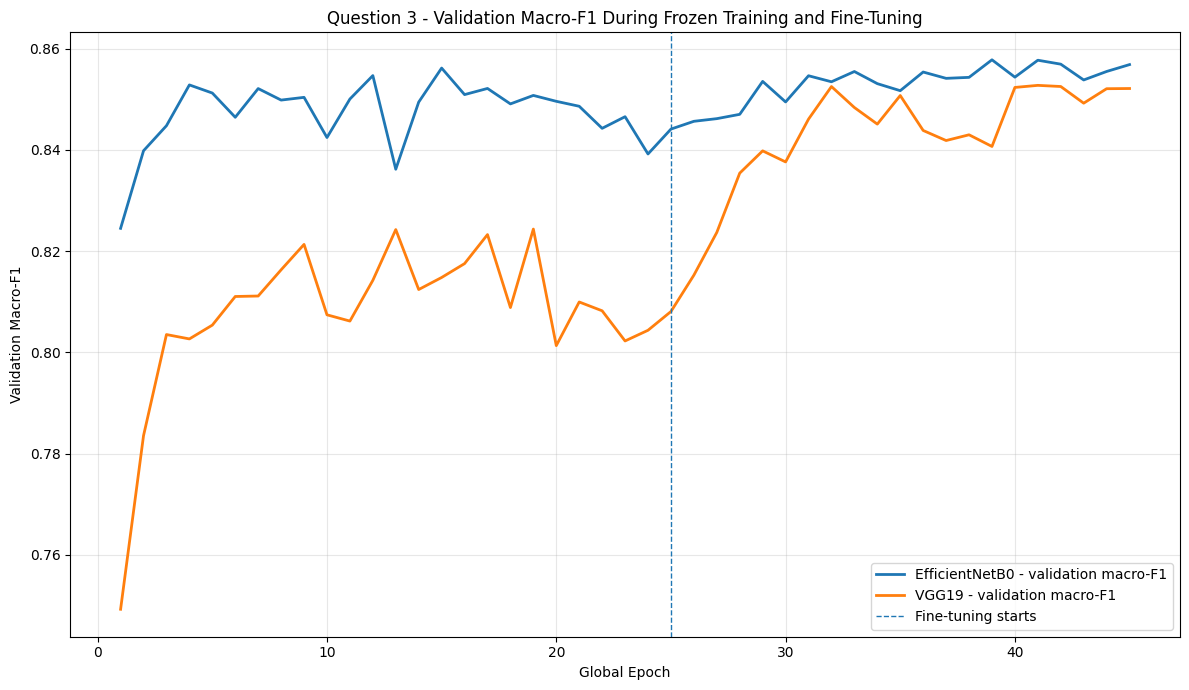

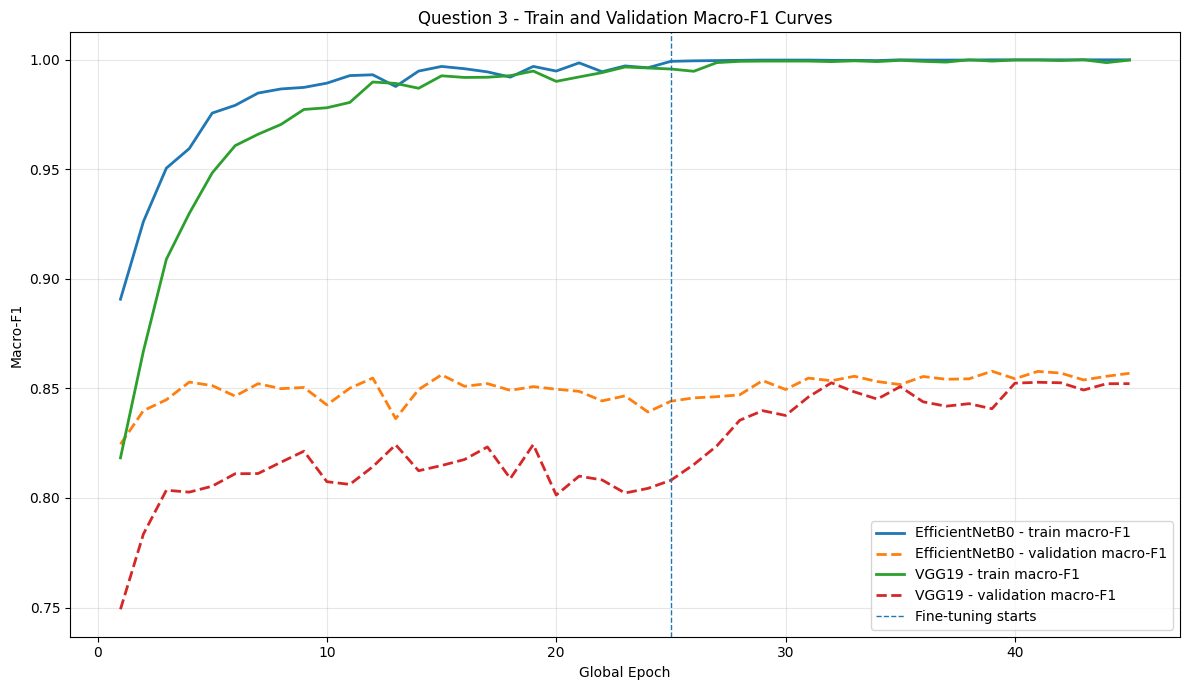

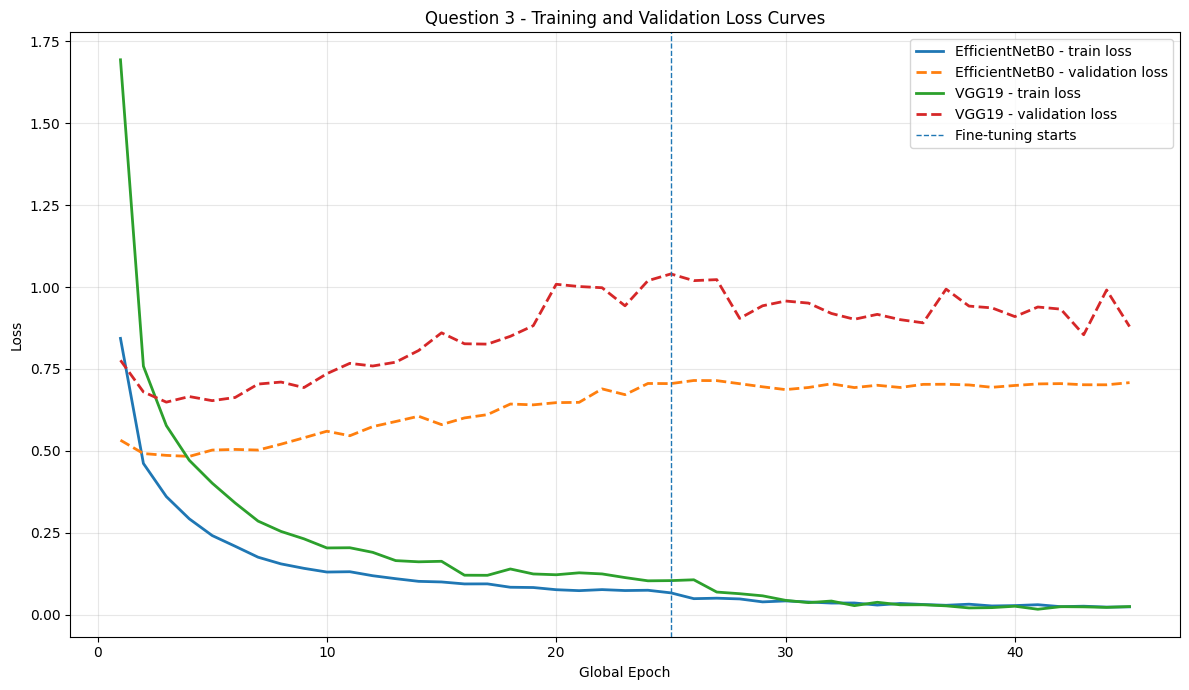

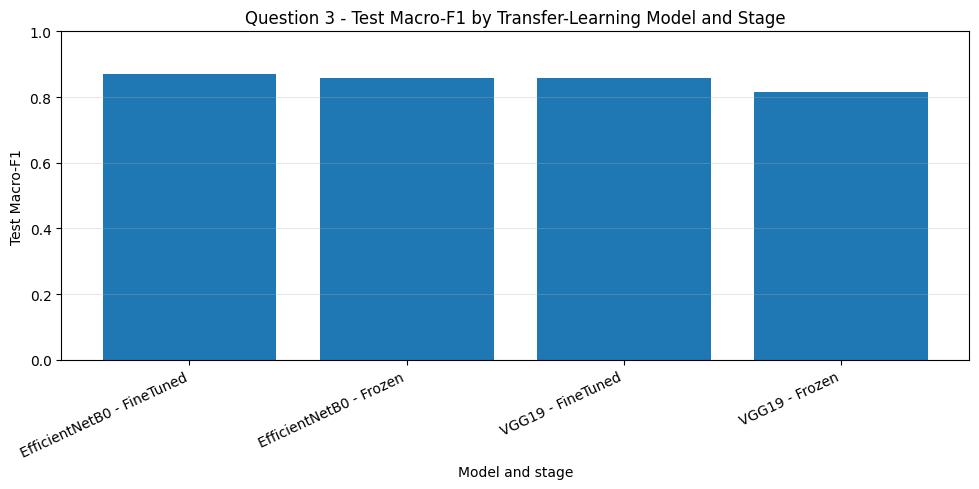

Frozen-base vs fine-tuned transfer-learning comparison:


,model,stage,input_size,epochs,learning_rate,trainable_parameters,final_val_macro_f1,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1
0,EfficientNetB0,FineTuned,128,20,0.00001,1816436,0.856875,0.857820,0.569227,0.8710,0.870182,0.870182
1,EfficientNetB0,Frozen,128,25,0.00100,333076,0.844123,0.856187,0.574618,0.8585,0.858083,0.858083
2,VGG19,FineTuned,128,20,0.00001,9575700,0.852146,0.852770,0.863211,0.8570,0.857736,0.857736
3,VGG19,Frozen,128,25,0.00100,136468,0.808070,0.824364,0.961141,0.8165,0.816207,0.816207


Best Question 3 model by test macro-F1:
  EfficientNetB0 - FineTuned (test macro-F1 = 0.8702, test accuracy = 0.8710)


In [ ]:
# ============================================================
# Question 3 - Cell 3
# Transfer-learning plots and final evaluation table
# ============================================================

# -----------------------------
# Load saved Q3 results
# -----------------------------

if not Q3_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {Q3_RESULTS_PATH}. Run Q3 Cell 2 first."
    )

if not Q3_HISTORY_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {Q3_HISTORY_PATH}. Run Q3 Cell 2 first."
    )

q3_results_df = pd.read_csv(Q3_RESULTS_PATH)
q3_history_df = pd.read_csv(Q3_HISTORY_PATH)

q3_results_df = q3_results_df.sort_values(
    "test_macro_f1",
    ascending=False,
).reset_index(drop=True)

q3_history_df = q3_history_df.sort_values(
    ["model", "global_epoch"],
    ascending=True,
).reset_index(drop=True)

print("Question 3 final transfer-learning results:")
display(q3_results_df)


# -----------------------------
# Plot validation macro-F1 curves
# -----------------------------

plt.figure(figsize=(12, 7))

for model_name in q3_history_df["model"].unique():
    model_history = q3_history_df[
        q3_history_df["model"] == model_name
    ].copy()

    plt.plot(
        model_history["global_epoch"],
        model_history["val_macro_f1"],
        label=f"{model_name} - validation macro-F1",
        linewidth=2,
    )

plt.axvline(
    x=FROZEN_EPOCHS,
    linestyle="--",
    linewidth=1,
    label="Fine-tuning starts",
)

plt.title("Question 3 - Validation Macro-F1 During Frozen Training and Fine-Tuning")
plt.xlabel("Global Epoch")
plt.ylabel("Validation Macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Plot train and validation macro-F1 curves
# -----------------------------

plt.figure(figsize=(12, 7))

for model_name in q3_history_df["model"].unique():
    model_history = q3_history_df[
        q3_history_df["model"] == model_name
    ].copy()

    plt.plot(
        model_history["global_epoch"],
        model_history["train_macro_f1"],
        label=f"{model_name} - train macro-F1",
        linewidth=2,
    )

    plt.plot(
        model_history["global_epoch"],
        model_history["val_macro_f1"],
        linestyle="--",
        label=f"{model_name} - validation macro-F1",
        linewidth=2,
    )

plt.axvline(
    x=FROZEN_EPOCHS,
    linestyle="--",
    linewidth=1,
    label="Fine-tuning starts",
)

plt.title("Question 3 - Train and Validation Macro-F1 Curves")
plt.xlabel("Global Epoch")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Plot loss curves
# -----------------------------

plt.figure(figsize=(12, 7))

for model_name in q3_history_df["model"].unique():
    model_history = q3_history_df[
        q3_history_df["model"] == model_name
    ].copy()

    plt.plot(
        model_history["global_epoch"],
        model_history["loss"],
        label=f"{model_name} - train loss",
        linewidth=2,
    )

    plt.plot(
        model_history["global_epoch"],
        model_history["val_loss"],
        linestyle="--",
        label=f"{model_name} - validation loss",
        linewidth=2,
    )

plt.axvline(
    x=FROZEN_EPOCHS,
    linestyle="--",
    linewidth=1,
    label="Fine-tuning starts",
)

plt.title("Question 3 - Training and Validation Loss Curves")
plt.xlabel("Global Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Bar plot: test macro-F1 by model and stage
# -----------------------------

q3_bar_df = q3_results_df.copy()
q3_bar_df["model_stage"] = q3_bar_df["model"] + " - " + q3_bar_df["stage"]

plt.figure(figsize=(10, 5))

plt.bar(
    q3_bar_df["model_stage"],
    q3_bar_df["test_macro_f1"],
)

plt.title("Question 3 - Test Macro-F1 by Transfer-Learning Model and Stage")
plt.xlabel("Model and stage")
plt.ylabel("Test Macro-F1")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, max(1.0, q3_bar_df["test_macro_f1"].max() + 0.05))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Frozen vs fine-tuned compact comparison
# -----------------------------

q3_stage_comparison_df = q3_results_df[
    [
        "model",
        "stage",
        "input_size",
        "epochs",
        "learning_rate",
        "trainable_parameters",
        "final_val_macro_f1",
        "best_val_macro_f1",
        "test_loss",
        "test_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
    ]
].sort_values(
    ["model", "stage"],
    ascending=True,
).reset_index(drop=True)

print("Frozen-base vs fine-tuned transfer-learning comparison:")
display(q3_stage_comparison_df)


# -----------------------------
# Best transfer-learning result
# -----------------------------

q3_best_row = q3_results_df.iloc[0]

print("Best Question 3 model by test macro-F1:")
print(
    f"  {q3_best_row['model']} - {q3_best_row['stage']} "
    f"(test macro-F1 = {q3_best_row['test_macro_f1']:.4f}, "
    f"test accuracy = {q3_best_row['test_accuracy']:.4f})"
)

## **Question 3: Results and Comments**
---

Question 3 applies **transfer learning** instead of training a CNN from scratch. Two ImageNet-pretrained convolutional networks were used:

- `VGG19`
- `EfficientNetB0`

For both models, the original ImageNet classifier was removed by using:

```python
include_top=False
weights="imagenet"
```

Then, a new classifier head was added for the 20 selected CIFAR-100 classes. The CIFAR images were resized from:

$$
32 \times 32 \times 3
$$

to:

$$
128 \times 128 \times 3
$$

This gives the pretrained networks a more suitable input resolution than the original CIFAR size, while still remaining lighter than the standard ImageNet resolution:

$$
224 \times 224
$$

Each model was trained in two stages:

1. **Frozen-base training:** the pretrained convolutional base was frozen and only the new classification head was trained for 25 epochs.
2. **Fine-tuning:** the last part of the pretrained base was unfrozen and trained with a much smaller learning rate for 20 additional epochs.

The fine-tuning strategy was deliberately conservative:

| Model | Fine-Tuning Strategy |
|---|---|
| `VGG19` | Unfreeze only the final convolutional block, `block5_*` |
| `EfficientNetB0` | Unfreeze only the last 30 layers, while keeping Batch Normalization layers frozen |

This is important because fine-tuning too many pretrained layers on a small dataset can quickly destroy useful pretrained features and cause overfitting.

---

### **Final Test-Set Comparison**

The final transfer-learning results were:

| Model | Stage | Trainable Parameters | Test Accuracy | Test Macro-$F_1$ | Test Weighted-$F_1$ | Test Loss |
|---|---|---:|---:|---:|---:|---:|
| `EfficientNetB0` | Fine-tuned | 1,816,436 | **0.8710** | **0.8702** | **0.8702** | **0.5692** |
| `EfficientNetB0` | Frozen | 333,076 | 0.8585 | 0.8581 | 0.8581 | 0.5746 |
| `VGG19` | Fine-tuned | 9,575,700 | 0.8570 | 0.8577 | 0.8577 | 0.8632 |
| `VGG19` | Frozen | 136,468 | 0.8165 | 0.8162 | 0.8162 | 0.9611 |

The best model is therefore:

$$
\text{EfficientNetB0 - FineTuned}
$$

with:

$$
\text{test macro-}F_1 = 0.8702
$$

and:

$$
\text{test accuracy} = 0.8710
$$

This is the best result obtained in the whole assignment.

---

### **Frozen-Base Training**

The frozen-base results are already very strong. This shows the main benefit of transfer learning: the pretrained convolutional layers already contain useful general-purpose visual features learned from ImageNet.

`EfficientNetB0` performs especially well even before fine-tuning, reaching:

$$
\text{test macro-}F_1 = 0.8581
$$

with only the new classifier head trained. This means that the pretrained EfficientNet feature extractor transfers very effectively to the selected CIFAR-100 classes.

`VGG19` also benefits from pretrained features, but its frozen-base result is lower:

$$
\text{test macro-}F_1 = 0.8162
$$

This suggests that the fixed VGG19 representation is useful, but less directly suited to this reduced-resolution CIFAR task than EfficientNetB0.

---

### **Effect of Fine-Tuning**

Fine-tuning improves both models, but the improvement is different.

For `VGG19`, fine-tuning gives a substantial improvement:

$$
0.8162 \rightarrow 0.8577
$$

in test macro-$F_1$. This indicates that the frozen VGG19 features were not fully adapted to the target dataset, and unfreezing the final convolutional block allowed the model to adjust higher-level features to the 20 selected CIFAR-100 classes.

For `EfficientNetB0`, the frozen model was already very strong, so the improvement from fine-tuning is smaller but still meaningful:

$$
0.8581 \rightarrow 0.8702
$$

This confirms that the pretrained EfficientNetB0 representation was already highly transferable, while fine-tuning the final layers provided an additional adaptation benefit.

The validation macro-$F_1$ curves also support this interpretation. `EfficientNetB0` starts with high validation performance very early in frozen training and remains stable. `VGG19` starts lower, but improves clearly after fine-tuning begins. This means that fine-tuning is especially important for VGG19, while EfficientNetB0 is already strong as a frozen feature extractor.

---

### **Comparison with Training from Scratch**

The transfer-learning models outperform all models trained from scratch in Questions 1 and 2.

The best regularized `MyCNN` from Question 2 achieved:

$$
\text{test macro-}F_1 = 0.6607
$$

while the best transfer-learning model achieved:

$$
\text{test macro-}F_1 = 0.8702
$$

This is a large improvement of approximately:

$$
0.8702 - 0.6607 = 0.2095
$$

The difference is expected. In Questions 1 and 2, all CNNs were trained only on the selected CIFAR-100 subset. In Question 3, the convolutional bases were pretrained on ImageNet, so they already contained rich visual features such as edges, textures, object parts, and higher-level patterns. The new classifier head only had to adapt these features to the 20 target classes.

---

### **Overfitting and Loss Behavior**

Both transfer-learning models reach very high training macro-$F_1$ scores, close to 1.0. However, unlike the from-scratch models in Question 1, the validation and test scores remain much higher. This indicates that the pretrained features generalize much better.

There is still some overfitting, especially visible in the gap between training and validation macro-$F_1$. The validation loss curves also show that the models become very confident on the training set. However, the final test macro-$F_1$ scores remain strong, so the overfitting is much less harmful than in the from-scratch setting.

`EfficientNetB0` has the best loss behavior. Its fine-tuned test loss is much lower than the fine-tuned VGG19 test loss:

$$
0.5692 \quad \text{vs.} \quad 0.8632
$$

This suggests that EfficientNetB0 produces better-calibrated and more reliable predictions on the test set.

---

### **Conclusion**

Question 3 shows that transfer learning is the most effective approach for this classification problem. The pretrained models achieve much higher performance than the CNNs trained from scratch, because they reuse visual representations learned from a much larger dataset.

The best overall model is **fine-tuned EfficientNetB0**. It achieves the highest test macro-$F_1$, highest test accuracy, and lowest test loss, while using far fewer trainable parameters during fine-tuning than VGG19. Therefore, among all models tested in the assignment, `EfficientNetB0 - FineTuned` is the strongest and most reliable final model for the selected 20-class CIFAR-100 image-classification task.

## **Overall Results Summary**
---

This exercise compared three levels of CNN-based image-classification approaches on the selected 20-class CIFAR-100 subset:

1. **Training CNNs from scratch** using LeNet, AlexNet, VGG, and a custom `MyCNN`.
2. **Regularizing the best custom CNN** using dropout and data augmentation.
3. **Applying transfer learning** using ImageNet-pretrained `VGG19` and `EfficientNetB0`.

The results show a clear progression: the custom CNN improves over the historical from-scratch architectures, regularization improves its generalization behavior, and transfer learning gives the strongest overall performance.

---

### **Question 1 - CNNs trained from scratch**

| Rank | Model | Parameters | Test Accuracy | Test Macro-$F_1$ | Test Weighted-$F_1$ |
|---:|---|---:|---:|---:|---:|
| 1 | `MyCNN` | 307,444 | 0.6205 | **0.6309** | **0.6309** |
| 2 | `VGG` | 816,692 | 0.5815 | 0.5757 | 0.5757 |
| 3 | `AlexNet` | 2,038,932 | 0.5085 | 0.5016 | 0.5016 |
| 4 | `LeNet` | 83,976 | 0.3805 | 0.3780 | 0.3780 |

The best model in Question 1 was `MyCNN`. It achieved the best balance between capacity and generalization, outperforming the adapted LeNet, AlexNet, and VGG models trained from scratch.

---

### **Question 2 - MyCNN regularization**

| Rank | Variant | Dropout | Augmentation | Test Accuracy | Test Macro-$F_1$ | Overfitting Gap |
|---:|---|---:|---|---:|---:|---:|
| 1 | `MyCNN_Best_Dropout_Augmentation` | 0.3 | medium | 0.6595 | **0.6607** | **0.1082** |
| 2 | `MyCNN_Baseline` | 0.0 | none | 0.6560 | 0.6596 | 0.2810 |
| 3 | `MyCNN_Best_Augmentation_Only` | 0.0 | light | **0.6645** | 0.6544 | 0.1384 |
| 4 | `MyCNN_Best_Dropout_Only` | 0.2 | none | 0.5765 | 0.5698 | 0.2199 |

The best regularized model was `MyCNN_Best_Dropout_Augmentation`. Although the baseline was close in test macro-$F_1$, the combined dropout and augmentation model had a much smaller overfitting gap, making it the most stable and reliable `MyCNN` variant.

---

### **Question 3 - Transfer learning**

| Rank | Model | Stage | Trainable Parameters | Test Accuracy | Test Macro-$F_1$ | Test Weighted-$F_1$ |
|---:|---|---|---:|---:|---:|---:|
| 1 | `EfficientNetB0` | Fine-tuned | 1,816,436 | **0.8710** | **0.8702** | **0.8702** |
| 2 | `EfficientNetB0` | Frozen | 333,076 | 0.8585 | 0.8581 | 0.8581 |
| 3 | `VGG19` | Fine-tuned | 9,575,700 | 0.8570 | 0.8577 | 0.8577 |
| 4 | `VGG19` | Frozen | 136,468 | 0.8165 | 0.8162 | 0.8162 |

The best model in Question 3 was `EfficientNetB0 - FineTuned`. It achieved the best performance of the whole assignment, showing the strong advantage of using ImageNet-pretrained convolutional features and then adapting the final layers to the target CIFAR-100 subset.

---

### **Best result from each question**

| Question | Best model | Test Accuracy | Test Macro-$F_1$ |
|---|---|---:|---:|
| Question 1 | `MyCNN` | 0.6205 | 0.6309 |
| Question 2 | `MyCNN_Best_Dropout_Augmentation` | 0.6595 | 0.6607 |
| Question 3 | `EfficientNetB0 - FineTuned` | **0.8710** | **0.8702** |

Overall, the results show that architectural adaptation and regularization both improve performance, but transfer learning produces the largest gain. The final best model is:

$$
\text{EfficientNetB0 - FineTuned}
$$

with:

$$
\text{test macro-}F_1 = 0.8702
$$

This confirms that pretrained CNNs are especially effective when the available dataset is relatively small compared with large-scale image-classification datasets such as ImageNet.

## **Memory management: `TFRecord`**
---

Loading data in the way we did above, in the simple implementation example, is very convenient, but it is not efficient in terms of **memory management**.

More specifically, with this approach, the data are stored directly in variables. All these variables occupy the **RAM** of the CPU or GPU, which makes it difficult or even impossible to handle **large datasets** or to transform the data, for example when applying **data augmentation**.

To overcome this problem, we can use **data serialization** and store the data in medium-sized files, usually a few MB each, which can then be read sequentially.

The `TFRecord` format allows storing a sequence of **binary records**. Read more about [`TFRecord` and `tf.Example`](https://www.tensorflow.org/tutorials/load_data/tfrecord), as well as [`tf.data`](https://www.tensorflow.org/guide/data), which is used to build TensorFlow input pipelines.

Note that, with this method, you need to import `tensorflow_datasets` and use `tfds.load`, so that the dataset is stored on disk as `TFRecord` files. You can see an example [here](https://colab.research.google.com/github/tensorflow/datasets/blob/master/docs/overview.ipynb).

Of course, we can also convert the dataset's **raw data**, such as `.jpg` image files, into the `TFRecord` format, as shown [here](https://towardsdatascience.com/working-with-tfrecords-and-tf-train-example-36d111b3ff4d).

## **Disclaimer**
---

All work submitted in this assignment is **entirely my own**. I independently designed the models, selected parameters, and made all implementation and evaluation decisions.

**AI-based tools were used solely for support purposes**, including:
- **Formatting and organizing** markdown cells for improved clarity,
- **Troubleshooting specific coding issues**,
- **Writing code snippets** based on my own logic and instructions, and
- **Translating content from Greek to English** for documentation and clarity.

At no point was AI used to generate or influence the **core logic**, design choices, or solutions required for the assignment.
